# 日历计算习题

此处展示如何用本软体提供的函数处理较复杂的日历计算，建议用家先按入门指南及进阶指引熟悉本软体的基本函数。为了增加计算效率，这里会用到入门指南及进阶指都没有提及的函数。

In [1]:
import ChineseCalendar_py.calendar_conversion as cc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 建立中历物件实例
cal = cc.calendar_conversion('ChiS')

## 历法测验题

[历法测验网页](https://ytliu0.github.io/ChineseCalendar/simpleQuiz_simp.html)最后一条加分题要从两张台湾电影截图断定某朔日的公历日期。

从截图可以得出若干讯息:(1)某农历月的初一在某公历月的第29日, 而且是星期三; (2)上一个农历月是小月; (3)下一个公历月的第5日是星期三, 并且在台湾是假期。从电影剧情可推出这月历应该在1990年与2011年之间, 而且很可能接近2005年。

欲求公历月的29日和下一个月的5日都是星期三，由此推出欲求的公历月有31日，所以(A)欲求的公历月只能是1月、3月、5月、7月、8月、10月或12月;(B)某农历月的初一在欲求公历月的29日并且是星期三;(C)上一个农历月是小月。

试找出满足(A)-(C)条件的日期。

下面的`check_conditions()`函数用来检查公历y年m月29日是否满足(B)和(c)的条件，`find_dates(y1, y2)`函数则输出从公元y1至y2年所有符合(A)-(C)条件的日期。

In [3]:
def check_conditions(cdate, y, m):
    # 判别(B)和(c)条件的辅助函数
    if cdate['Chinese ymd'][2] != 1: return False
    if cdate['Week'][1] != 3: return False
    return cal.western_to_chinese_date(y, m, 28)['Chinese ymd'][2]==29

def find_dates(y1, y2):
    dates = []
    for y in range(y1, y2+1):
        for m in [1, 3, 5, 7, 8, 10, 12]:
            cdate = cal.western_to_chinese_date(y, m, 29)
            if check_conditions(cdate, y, m):
                dates += [cdate]
    return dates

找出满足(A)-(C)条件在1991年至2011年的所有日期。

In [4]:
find_dates(1991,2011)

[{'Western ymd': [2006, 3, 29],
  'Western calendar': '格里历',
  'JDN': 2453824,
  'Chinese ymd': [2006, 3, 1],
  'cyear': 2006,
  'cdate': '三月初一',
  'sexagenary year': ['丙戌', '狗', 23],
  'jian': ['建壬辰', 29],
  'Nday_cmonth': 30,
  'sexagenary date': ['丁巳', 54],
  'Week': ['星期三', 3],
  'period': '现代 (1912 - )',
  'Chinese calendar': '紫金历'}]

结果是在1991-2011年，只有一个日期满足所有条件：2006年3月29日，这就是正确答案。

[历法测验网页](https://ytliu0.github.io/ChineseCalendar/simpleQuiz_simp.html)的题解说在1912-2100年间有四个日期满足(A)-(C)条件，以下指令验证此说。

In [5]:
find_dates(1912,2100)

[{'Western ymd': [1913, 10, 29],
  'Western calendar': '格里历',
  'JDN': 2420070,
  'Chinese ymd': [1913, 10, 1],
  'cyear': 1913,
  'cdate': '十月初一',
  'sexagenary year': ['癸丑', '牛', 50],
  'jian': ['建癸亥', 60],
  'Nday_cmonth': 30,
  'sexagenary date': ['癸未', 20],
  'Week': ['星期三', 3],
  'period': '现代 (1912 - )',
  'Chinese calendar': '时宪历'},
 {'Western ymd': [1957, 5, 29],
  'Western calendar': '格里历',
  'JDN': 2435988,
  'Chinese ymd': [1957, 5, 1],
  'cyear': 1957,
  'cdate': '五月初一',
  'sexagenary year': ['丁酉', '鸡', 34],
  'jian': ['建丙午', 43],
  'Nday_cmonth': 30,
  'sexagenary date': ['辛丑', 38],
  'Week': ['星期三', 3],
  'period': '现代 (1912 - )',
  'Chinese calendar': '紫金历'},
 {'Western ymd': [2006, 3, 29],
  'Western calendar': '格里历',
  'JDN': 2453824,
  'Chinese ymd': [2006, 3, 1],
  'cyear': 2006,
  'cdate': '三月初一',
  'sexagenary year': ['丙戌', '狗', 23],
  'jian': ['建壬辰', 29],
  'Nday_cmonth': 30,
  'sexagenary date': ['丁巳', 54],
  'Week': ['星期三', 3],
  'period': '现代 (1912 - )',
  'Ch

## 《红楼梦》提及的四月二十六日未时交芒种

1630-1800年间哪年四月二十六日未时交芒种? 未时是指 13:00-15:00 这两小时时间，清朝历书载的时刻全是北京地方视时。

此问题来自《红楼梦》(又称《石头记》)第二十七回的文字：「至次日乃是四月二十六日，原来这日未时交芒种节。」有学者认为小说所说历日对应的年份对作者有重要意义。现试找出1630-1800年间哪年四月二十六日未时交芒种。

首先找出1630-1800年间哪年芒种落在四月二十六日。进阶指引提到预设中历在-103年至2200年的历日用查表法获取，朔闰日朔存于`cal.calData` numpy array，历书节气存于 `cal.calSterm` numpy array。芒种的日期(离公历年1月0日的日数)在`cal.calSterm[:,10]`，四月朔的日期在`cal.calData[:,3]`。如果芒种在四月二十六日，则`cal.calSterm[:,10] - cal.calData[:,3]` = 25。年份 y 在`cal.calData`和`cal.calSterm`行数是`y - cal.ybeg_default + 1`，`cal.ybeg_default`是常数。

因此很容易用`cal.calData` 和 `cal.calSterm` 找出1630-1800年间哪年芒种落在四月二十六日。

In [6]:
J5d = cal.calSterm[:,10] - cal.calData[:,3]
years = [y for y in range(1630,1800) if J5d[y - cal.ybeg_default + 1]==25]
print(years)

[1649, 1668, 1687, 1706, 1725, 1736, 1782]


民国以前中国习惯用帝皇年号纪年，以下`chinese_year_name(cal, cyear, region='default', li=None)`函数转中历 y 年为帝皇年号，如果没有年号，则用干支纪年，`cal` 是中历物件实例，`cyear`是中历年数，取公历年份与中历年重叠最多的年份，`region`是中国地域或朝代，用于选择分裂时代某政权年号，默认值是'default'，即预设中历的选择，`li`参数只适用于古六历的历法，默认值'None'表示程式会根据`region`自动选择。此函数用本软件的`ChineseCalendar_py.era_name_lookup()`函数获取年号。年干支的计算用[干支网页](https://ytliu0.github.io/ChineseCalendar/sexagenary_chinese.html)的年干支计算公式。

In [7]:
def chinese_year_name(cal, cyear, region='default', li=None):
    cy = 'NA'
    if cyear < 1912:
        # 中历年号
        cy = cc.era_name_lookup(cal.lang, cyear, region, li)
    if cy=='NA':
        # 干支纪年
        cy = cal.stem[(cyear + 6) % 10] + cal.branch[(cyear + 8) % 12] + '年'
    cy += '({}年)'.format(cyear)
    return cy

In [8]:
print([chinese_year_name(cal, x) for x in years])

['清世祖顺治六年(1649年)', '清圣祖康熙七年(1668年)', '清圣祖康熙二十六年(1687年)', '清圣祖康熙四十五年(1706年)', '清世宗雍正三年(1725年)', '清高宗乾隆元年(1736年)', '清高宗乾隆四十七年(1782年)']


历书节气只提供日期，没有时刻，清朝节气时刻可用我的[时宪历气朔时刻网页](http://ytliu.epizy.com/Shixian/times_simp.html)查得，当然最权威的资料是清朝钦天监编的官方历书，下表将芒种在上面算出的那几年的日期和时刻列出。

|公历年       |中历年       |  用时宪历算出的时刻   | 官方历书载的时刻    |
|------------|------------|--------------------|----------------------|
|1649        |顺治六年     |戌初二刻十二分 (19:42) |戌时                 |      
|1668\*      |康熙七年     |巳初三刻十一分 (09:56) |四月廿七 乙未辰初一刻 |
|1687        |康熙二十六年  |夜子初三刻二分 (23:47) |夜子初     |
|1706        |康熙四十五年  |**未初三刻十三分 (13:58)**|未时    |
|1725        |雍正三年     |寅正初刻八分 (04:08)  |寅正初刻八分 (04:08)|
|1736        |乾隆元年     |亥初一刻五分 (21:20)  |亥初一刻四分 (21:19)|
|1782        |乾隆四十七年  |子正一刻 (00:15)     |子正初刻十四分 (00:14)|

\* 康熙六年至八年因历狱复用明朝大统历

表中官方历书取自《大清七政经纬躔度时宪历》(康熙七年和雍正三年)、《大清时宪书》(乾隆元年和四十七年)、《御定万年书》(顺治六年、康熙二十六年和四十五年)。

由此可见四月二十六日未时交芒种的年份是康熙四十五年(1706)。当然，我可以将[时宪历气朔时刻网页](http://ytliu.epizy.com/Shixian/times_simp.html)的清朝节气时刻计算加入本软体套件，这样就不须要查那几年的芒种时刻了，不过还是应该用官方历书核对资料。

## 十九世纪何年的7月9日是星期五？

这问题来自HASTRO论坛："I was attempting to date a manuscript diary (not astronomical) from the 19th century. The diarist recorded the days of the week and the dates of his entries, but not the year, and I was trying to use the given information to narrow the list of years in which the diary might have been written..." (「我试图找出一则十九世纪的日记(非天文类)年份，日记记录了星期几和日期，但没有记录年份。我试图利用这些资讯来缩小日记可能的写作年份范围⋯⋯」)

以下是「快速但笨拙」的方法找出十九世纪7月9日落在星期五的所有年份。

In [9]:
years = [y for y in range(1801, 1901) if cal.western_to_chinese_date(y,7,9)['Week'][1]==5]
print('十九世纪7月9日落在星期五的所有年份：\n', years)

十九世纪7月9日落在星期五的所有年份：
 [1802, 1813, 1819, 1824, 1830, 1841, 1847, 1852, 1858, 1869, 1875, 1880, 1886, 1897]


这方法之所以笨拙，是因为函数 `cal.western_to_chinese_date()`还计算不必要的中历日期。

其实解这道题不须用本软体，用简单的 python 指令就可以了。较好的解题法是留意到公历y年7月9日至 y+1 年 7月9日的日数是365(如果y+1年不是闰年)或366日(如果y+1年是闰年)，而 365 = 7×52 + 1 ，366 = 7×52 + 2。因此如果y+1年不是闰年y+1 年 7月9日的星期数是y年7月9日的加一； 如果y+1年是闰年，y+1 年 7月9日的星期数是y年7月9日的加二。引入星期数 W，W＝0表示星期日，W＝1示星期一,⋯⋯, W=6示星期六。根据这规则可写成 W 在 y 年的差分方程：
$$
W(y+1) - W(y) = \left\{ 
    \begin{array}{ll} 2 & 如果 y+1 年是闰年 \\
    1 & 如果 y+1 年不是闰年 \end{array}
\right.
$$
格里历的闰年法则是如果 y 是4的倍数但不是100的倍数或 y 是400的倍数，上述差分方程的解是

W(y) = (C + y + \[y/4\] - \[y/100\] + \[y/400 \]) % 7 

此处\[x\]表示不大于x的最大整数，% 表示求余数。只要知道某年7月9日是星期几，便可求得常数 C。从2025年的日历得知2025年7月9日是星期三(W=3)，由此推出 C = 0。

根据这些资料，便可轻宜算出十九世纪7月9日落在星期五的所有年份：

In [10]:
W = lambda y: (y + y//4 - y//100 + y//400) % 7
years2 = [y for y in range(1801,1901) if W(y)==5]
print('十九世纪7月9日落在星期五的所有年份：\n', years2)
print('与刚才笨拙方法算出的年份一致：', years2==years)

十九世纪7月9日落在星期五的所有年份：
 [1802, 1813, 1819, 1824, 1830, 1841, 1847, 1852, 1858, 1869, 1875, 1880, 1886, 1897]
与刚才笨拙方法算出的年份一致： True


由此可见用这方法算出的结果与用刚才笨拙方法算出的一致。

正如HASTRO论坛上其他两位用户所指出的，有一种无需任何计算就能轻松查明年份的方法，那就是查阅万年历(perpetual calendar)。虽然涵盖两千多年的中国万年历有数百页之多，但西方万年历只需两三份表格即可。 

解决此问题的万年历可在1961年版 *Explanatory Supplement to the Astronomical Almanac* 的表[14.2](https://archive.org/details/astronomicalalmanac1961/page/n429/mode/1up)和[14.9](https://archive.org/details/astronomicalalmanac1961/page/n437/mode/1up)中找到。

从第一个表格中得知7月9日是星期五年份的首字母(dominical letter)为C。从第二个表格中，可以确定首字母为C或DC（闰年）的年份。答案当然与上面得出的年份相同。

## 中历新年在格里历的日期

中历新年在格里历1月下旬至2月中旬之间浮动。现考察中历新年在格里历的日期，由于格里历在1582年10月15日才被采用，这里只考察1582年(明神宗万历十年)后的中历新年。

预设中历新年的公历日期就存在numpy array `cal.calDate`的第一栏，以公历年日数表示，例如25表示1月25日，32表示2月1日，50表示2月19日等。

In [11]:
new_year_day = np.copy(cal.calData[(1584-cal.ybeg_default):,0])
print(min(new_year_day), max(new_year_day))

21 51


由此可见预设中历新年于1583-2200年间落在格里历的1月21日至2月20日。
以下显示中历新年于1583-2200年在格里历日期的归一化直方图。

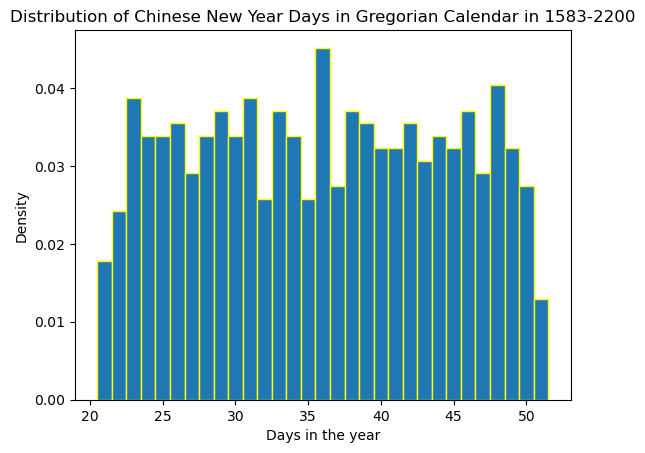

In [12]:
plt.hist(new_year_day, bins=np.arange(21,53)-0.5, edgecolor='yellow', density=True)
plt.title('Distribution of Chinese New Year Days in Gregorian Calendar in 1583-2200')
plt.xlabel('Days in the year')
plt.ylabel('Density')
plt.show()

可见中历新年于1583-2200较少落在1月21日和2月20日，但在之间的日期大致均匀分布。

2200年后的中历新年可用本软体提供的《农历的编算和颁行》GB/T 33661-2017 方法计算(年份上限是3500年)，以下计算2201年至3500年的中历新年。

In [13]:
new_year_day_GBT = [cal.chinese_to_western_date(y, 1, 1, calendar='GBT')['Western ymd'] for y in range(2201, 3501)]
print(new_year_day_GBT[:10])

[[2201, 2, 4], [2202, 1, 25], [2203, 2, 13], [2204, 2, 2], [2205, 2, 20], [2206, 2, 9], [2207, 1, 29], [2208, 2, 17], [2209, 2, 6], [2210, 1, 26]]


这输出格式与刚才的公历日数不符合，但也很容易转为公历日数

In [14]:
new_year_day_GBT = np.array([(x[1]-1)*31 + x[2] for x in new_year_day_GBT])
print(new_year_day_GBT[:10])

[35 25 44 33 51 40 29 48 37 26]


In [15]:
print(min(new_year_day_GBT), max(new_year_day_GBT))

21 52


可见在2201-3500年中历新年落在格里历1月21日至2月21日。可将上面两个 numpy array 合并成1583-3500年中历新年日期数据，然后显示中历新年于1583-3500年在格里历日期的归一化直方图。

In [16]:
new_year_day_combined = np.append(new_year_day, new_year_day_GBT)

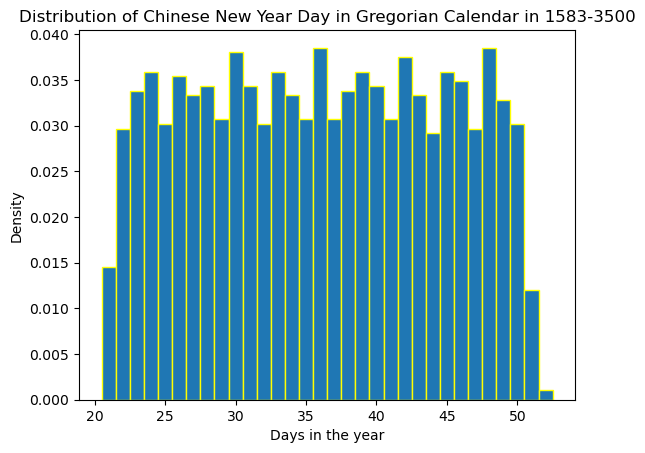

In [17]:
plt.hist(new_year_day_combined, bins=np.arange(21,54)-0.5, density=True, edgecolor='yellow')
plt.title('Distribution of Chinese New Year Day in Gregorian Calendar in 1583-3500')
plt.xlabel('Days in the year')
plt.ylabel('Density')
plt.show()

可见在1583-3500年间，中历新年甚少出现在2月21日，出现在1月21日和2月20日也比较少，中历新年较多落在1月22日至2月19日。

## 二十世纪冬至在公历的日期

冬至在中国历法相当重要，中历是阴阳历，「阴」跟月相，「阳」则跟节气。冬至在中历是一岁之始，即中历阳历年之始。

试考察冬至在1930-2000年间的日期和UT+8时刻。

In [18]:
# 建立气朔物件实体
sm = cc.sunMoon.sunMoon('ChiS')

In [19]:
# 1930-2000年冬至日期
Z11 = [[y, sm.st_mp(y)[0][-1][1]['dateString'], sm.st_mp(y)[0][-1][1]['timeString']] 
       for y in range(1930,2001)]
dfZ11 = pd.DataFrame(Z11, columns=['公历年', '日期', '时刻 (UT+8)'])
pd.set_option('display.max_rows', None)
display(dfZ11)

,公历年,日期,时刻 (UT+8)
0,1930,12月22日,21:39
1,1931,12月23日,03:30
2,1932,12月22日,09:14
3,1933,12月22日,14:57
4,1934,12月22日,20:49
5,1935,12月23日,02:37
6,1936,12月22日,08:27
7,1937,12月22日,14:22
8,1938,12月22日,20:13
9,1939,12月23日,02:06


可见冬至日期在12月21日至23日之间，出现最多的日期是12月22日。试看哪些年份冬至日期不在12月22日。

In [20]:
display(dfZ11[dfZ11['日期'] != '12月22日'])

,公历年,日期,时刻 (UT+8)
1,1931,12月23日,03:30
5,1935,12月23日,02:37
9,1939,12月23日,02:06
13,1943,12月23日,01:29
17,1947,12月23日,00:43
21,1951,12月23日,00:00
58,1988,12月21日,23:28
62,1992,12月21日,22:43
66,1996,12月21日,22:06
70,2000,12月21日,21:37


从表中得知从1952年至1987年，连续36年冬至都在12月22日，这种现象是可从理论上分析。

回归年有365天5小时48分45秒。这意味着，如果次年不是闰年，次年冬至时间平均晚5小时48分45秒；如果次年是闰年，次年冬至时间平均提前18小时11分15秒。

容易证明，（平均而言）如果 y 是闰年，并且 y 的冬至发生在 00:00 至 6:33:45 之间，则 y、y+1、y+2 和 y+3 的冬至都在同一天，并且 y+4 的冬至比 y 早 45 分钟。因此，如果闰年的冬至发生在6时33分左右，那么接下来35年的冬至都在同一天。

此计算仅考虑太阳的平均运动。如果查看数据，会发现1948年的冬至发生在12月22日6:33，而1951年的冬至在12月23日00:00。 1952年的冬至是5时43分，据以上分析，冬至将连续多年停留在12月22日，直到1984年冬至会落在12月21日。实际上，因日行盈缩，1984年的冬至仍然是在12月22日 0:23。因此，在接下来的三年中，冬至仍然落在12月22日，直到1988年才落在12月21日。

冬至在1952年至1987年落在12月22日，是用UT+8的日期，如果用UT为时间标准就不同了。以下计算冬至在1901-1960年的UT日期。

In [21]:
# 辅助函数提取冬至的 UT 日期和时刻
def Z11_ut(sm, y):
    # extract the UT Julian day of Z11
    jd0 = sm.st_mp(y)[0][-1][1]['jd0_ut']
    jd1 = sm.st_mp(y)[0][-1][1]['jd1_ut']
    # convert Julian day to Western date
    d = cc.CalDat(jd0, jd1)
    mon = ['{}月'.format(i+1) for i in range(12)]
    dateString = mon[d['mm']-1]+str(d['dd'])+'日'
    # extract the UT time of Z11
    h = 24*(jd1 - np.floor(jd1)) + 0.5/60
    hh = int(np.floor(h))
    mm = int(np.floor(60*(h - hh)))
    hh = ('0'+str(hh))[-2:]
    mm = ('0'+str(mm))[-2:]
    timeString = hh + ':' + mm
    return [y, dateString, timeString]

In [22]:
Z11_UT = [Z11_ut(sm,y) for y in range(1901,1961)]
dfZ11_UT = pd.DataFrame(Z11_UT, columns=['公历年', '日期', '时刻(UT)'])
display(dfZ11_UT)

,公历年,日期,时刻(UT)
0,1901,12月22日,12:37
1,1902,12月22日,18:36
2,1903,12月23日,00:20
3,1904,12月22日,06:14
4,1905,12月22日,12:04
5,1906,12月22日,17:53
6,1907,12月22日,23:52
7,1908,12月22日,05:33
8,1909,12月22日,11:20
9,1910,12月22日,17:12


可见用了UT时间后，冬至的日期于1904-1939年连续36年落在格里历的12月22日。

## 计算两个日期之间的日数

使用儒略日数可以轻易完成此计算，某日的儒略日数是该日离逆推儒略历-4712年1月1日中午之间的日数。对于公历年 y、月 m 和日期 d（1582年10月4日之后用格里历；1582年10月15日前用儒略历；8年前用逆推儒略历），函数 `ChineseCalendar_py.getJDm(y, m , d)` 输出该日期午夜的儒略日期数。因此，两个公历日期 (y1, m1, d1) 和 (y2, m2, d2) 之间的日数为 `cc.getJDm(y2, m2 , d2) - cc.getJDm(y1, m1, d1)`。

试算1611年12月18日到2026年4月21日之间的日数。

In [23]:
print('1611年12月18日到2026年4月21日之间有{}日'.format(
cc.getJDm(2026, 4, 21) - cc.getJDm(1611, 12, 18)))

1611年12月18日到2026年4月21日之间有151335.0日


如果日期涉及中历，可用`.chinese_to_western_date()`输出的'JDN'字键取得该日正午的儒略日数。以下例子展示计算2021年端午节至2026年端午节之间的日数。

In [24]:
print('2021年端午节至2026年端午节之间有{}日'.format(
cal.chinese_to_western_date(2026, 5, 5)['JDN'] - cal.chinese_to_western_date(2021, 5, 5)['JDN']))

2021年端午节至2026年端午节之间有1831日


In [25]:
# 此指令计算中历2026年(丙午年)的日数
print('中历2026年(丙午年)有{}日'.format(
cal.chinese_to_western_date(2027, 1, 1)['JDN'] - cal.chinese_to_western_date(2026, 1, 1)['JDN']))

中历2026年(丙午年)有354日


## 冬至数九

冬至数九是中国民间传统一种计算寒天与春暖花开的方法，从冬至起每九天数一九(也有从冬至后第一个壬日数起之说)。从冬至到冬至后第八日为一九，冬至后第九日至第十七日为二九，冬至后第十八日至第二十六日为三九⋯⋯冬至后第72日至第80日为九九。由于冬至与春分之间有约九十日，数完九九后，距冬至已经八十一日，春分不久将至。

如上说，冬至是一岁之始，公历新年一般在冬至后10日左右，中历新年则在冬至后第二或第三个朔日。此处以公历年来标记岁，2026岁首在2025年的冬至，即2025年12月21日。

计算冬至数九的日期很简单，首先计算y岁冬至日朔。冬至在y岁的TDB+8儒略日数可用以下近似公式计算： 
$$
  JD_{Z11} \approx 2451534.717795358 + 365.242193(y-2000) - 2.84514\times 10^{-8} (y-2000)^2
$$
此公式是根据DE441算出-3500-3500年节气的 TDB+8 时刻用二次多项式拟合的，冬至精确的 TDB+8 时刻与此公式偏差不超过2.2日，而中国历史上的历书节气与DE441算出的常有几日偏差，这是因为清朝以前的历书节气是平气，没有计及日行盈缩，而DE441算出的节气是定气。因此不需要寻求更准确的拟合公式，也无需转 TDB+8 为 UT+8，此拟合公式只是用作搜索历书冬至的指引。

`cal.get_calendrical_solar_terms(calendar, jd1, jd2)` 函数用来获取从 UT+8 儒略日数 jd1 至 jd2 在某中历的所有历书节气。设定 jd1 = JD_{Z11}-10 及 jd2 = JD_{Z11} + 10，便可用此函数获取 y 岁的冬至日期。函数输出 tuple list \[\(lab1, jdn1\), \(lab2, jdn2\), ...\]；其中lab1， lab2，⋯⋯为节气标记，例如 'J1' 是正月节(立春)、'Z4' 是四月中(小满)等；jdn1，jdn2，⋯⋯为节气日期的正午儒略日数。冬至是十一月中('Z11')，获取冬至的正午儒略日数后，数九首日的正午儒略日数便可轻易求得，公历日期可用 `ChineseCalendar_py.CalDat(JDN)`函数计算。

当然，如果只需要预设中历的历书冬至不用这么麻烦，用`cal.calSterm` numpy array 的数据即可。这里介绍的`cal.get_calendrical_solar_terms()` 函数可以用来获取其他中历的历书节气。

`ChineseCalendar_py.calendar_conversion` class 有若干字串常数方便转数字为文字，例如`cal.wmonthName[]`存有`['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月']`。

下面`winter_9nines()`函数计算 y 岁内数九首日的公历日期。

In [26]:
def convert_JDN_Western_date(cal, JDN):
        # 转正午儒略日数 JDN 为公历日期
        date = cc.CalDat(JDN)
        return cal.wmonthName[date['mm']-1] + cal.wdayName[date['dd']-1]
        
def winter_9nines(cal, y, calendar='default'):
    # 计算 y 岁内数九首日的公历日期
    jd1 = 2451524.717795358 + 365.242193*(y-2000) - 2.84514e-8*(y-2000)**2
    calst = cal.get_calendrical_solar_terms(calendar, jd1, jd1+20)
    # y 岁历书冬至的 JDN
    JDN_Z11 = [x[1] for x in calst if x[0]=='Z11'][0]
    # 数九首日的 JDN 
    JDN_9nines = JDN_Z11 + 9*np.arange(9)
    out = {'岁':y}
    chi_num = ['一', '二', '三', '四', '五', '六', '七', '八', '九']
    for i in range(9):
        out['{}九'.format(chi_num[i])] = convert_JDN_Western_date(cal, JDN_9nines[i])
    return out

In [27]:
# 2025岁的数九首日
winter_9nines(cal, 2025)

{'岁': 2025,
 '一九': '12月21日',
 '二九': '12月30日',
 '三九': '1月8日',
 '四九': '1月17日',
 '五九': '1月26日',
 '六九': '2月4日',
 '七九': '2月13日',
 '八九': '2月22日',
 '九九': '3月3日'}

除了一九和二九首日落在公历2024年外，其他数九首日落在2025年。

以下列出 2020-2040岁数九首日的公历日期。

In [28]:
nines = [winter_9nines(cal, y) for y in range(2020, 2041)]
display(pd.DataFrame(nines))

,岁,一九,二九,三九,四九,五九,六九,七九,八九,九九
0,2020,12月22日,12月31日,1月9日,1月18日,1月27日,2月5日,2月14日,2月23日,3月3日
1,2021,12月21日,12月30日,1月8日,1月17日,1月26日,2月4日,2月13日,2月22日,3月3日
2,2022,12月21日,12月30日,1月8日,1月17日,1月26日,2月4日,2月13日,2月22日,3月3日
3,2023,12月22日,12月31日,1月9日,1月18日,1月27日,2月5日,2月14日,2月23日,3月4日
4,2024,12月22日,12月31日,1月9日,1月18日,1月27日,2月5日,2月14日,2月23日,3月3日
5,2025,12月21日,12月30日,1月8日,1月17日,1月26日,2月4日,2月13日,2月22日,3月3日
6,2026,12月21日,12月30日,1月8日,1月17日,1月26日,2月4日,2月13日,2月22日,3月3日
7,2027,12月22日,12月31日,1月9日,1月18日,1月27日,2月5日,2月14日,2月23日,3月4日
8,2028,12月22日,12月31日,1月9日,1月18日,1月27日,2月5日,2月14日,2月23日,3月3日
9,2029,12月21日,12月30日,1月8日,1月17日,1月26日,2月4日,2月13日,2月22日,3月3日


由于公历也是阳历，数九首日每年都落在大致相同的公历日期并不足为奇。

## 杂节气

除了二十四节气外，中国传统还有七十二侯，将每个节气之间分为三侯，不过现在已很少使用。

二十四节气和七十二侯都以太阳在黄道的位置而定，中国传统还有「杂节气」，用某些二十四节气和日干支来定。这里介绍五个杂节气：
- 入梅：定为芒种起算的第一个丙日，如果芒种的日天干是丙，则入梅在芒种日，否则在芒种后第一个丙日。
- 出梅：定为小暑起算的第一个未日。
- 三伏：中国民谚有「热在三伏」的说法，说「三伏」是一年最热的时候。「三伏」是「初伏」(又称「头伏」)、「中伏」和「末伏」的总称，初伏是从夏至算起的第三个庚日至第四个庚日前一日，中伏是从夏至算起的第四个庚日至立秋起算第一个庚日前一日，末伏是立秋起第一个庚日至第二个庚日前一日。

中国科学院紫金山天文台在《十年袖珍月历》说这些计算方法并没有什么科学道理，更多具有传统民俗意义。入梅和出梅算出的日期会与气象预报的入梅出梅日期不一致。

根据这些计算法则很容易编程式计算这些杂节气。这些杂节气涉及芒种(J5)、夏至(Z5)、小暑(J6)和立秋(J7)，可用`cal.get_calendrical_solar_terms(calendar, jd1, jd2)`获取这些节气的正午儒略日数JDN，jd1 可设为冬至后150日，jd2 可设为 jd1 + 150。有了这些节气的 JDN 后，可用[干支网页](https://ytliu0.github.io/ChineseCalendar/sexagenary_simp.html)的第(2)式计算节气的日天干或日地支，从而便可计算这些杂节气的 JDN 及公历日期。

以下`mixed_seasonal_markers(cal, y, calendar='default')`计算 y 岁中的五个杂节气，这些杂节气都落在公历 y 年。

In [29]:
def mixed_seasonal_markers(cal, y, calendar='default'):
    jd1 = 2451684.717795358 + 365.242193*(y-2000) - 2.84514e-8*(y-2000)**2
    # 获取历书芒种、小暑、夏至和立秋
    calst = cal.get_calendrical_solar_terms(calendar, jd1, jd1+150)
    JDN_J5 = [x[1] for x in calst if x[0]=='J5'][0]
    JDN_J6 = [x[1] for x in calst if x[0]=='J6'][0]
    JDN_Z5 = [x[1] for x in calst if x[0]=='Z5'][0]
    JDN_J7 = [x[1] for x in calst if x[0]=='J7'][0]
    stem_J5 = (JDN_J5 - 1) % 10 
    # 芒种距丙日的日数
    d = 2 - stem_J5 if stem_J5 < 3 else 12 - stem_J5
    # 入梅
    JDN_enp = JDN_J5 + d
    branch_J6 = (JDN_J6 + 1) % 12
    d = 7 - branch_J6 if branch_J6 < 8 else 19 - branch_J6
    # 出梅 
    JDN_exp = JDN_J6 + d
    stem_Z5 = (JDN_Z5-1) % 10
    d = 6 - stem_Z5 if stem_Z5 < 7 else 16 - stem_Z5
    JDN_1fu = JDN_Z5 + d + 20
    JDN_2fu = JDN_Z5 + d + 30
    stem_J7 = (JDN_J7-1) % 10 
    d = 6 - stem_J7 if stem_J7 < 7 else 16 - stem_J7
    JDN_3fu = JDN_J7 + d
    return {'年份':y, '入梅':convert_JDN_Western_date(cal, JDN_enp),
            '出梅':convert_JDN_Western_date(cal, JDN_exp),
            '初伏':convert_JDN_Western_date(cal, JDN_1fu),
            '中伏':convert_JDN_Western_date(cal, JDN_2fu),
            '末伏':convert_JDN_Western_date(cal, JDN_3fu)}

In [30]:
# 2026年的杂节气
print(mixed_seasonal_markers(cal,2026))

{'年份': 2026, '入梅': '6月11日', '出梅': '7月8日', '初伏': '7月15日', '中伏': '7月25日', '末伏': '8月14日'}


In [31]:
# 2020-2040年杂节气
fus = [mixed_seasonal_markers(cal, y) for y in range(2020, 2041)]
display(pd.DataFrame(fus))

,年份,入梅,出梅,初伏,中伏,末伏
0,2020,6月12日,7月15日,7月16日,7月26日,8月15日
1,2021,6月7日,7月10日,7月11日,7月21日,8月10日
2,2022,6月12日,7月17日,7月16日,7月26日,8月15日
3,2023,6月7日,7月12日,7月11日,7月21日,8月10日
4,2024,6月11日,7月6日,7月15日,7月25日,8月14日
5,2025,6月6日,7月13日,7月20日,7月30日,8月9日
6,2026,6月11日,7月8日,7月15日,7月25日,8月14日
7,2027,6月6日,7月15日,7月20日,7月30日,8月9日
8,2028,6月10日,7月9日,7月14日,7月24日,8月13日
9,2029,6月5日,7月16日,7月19日,7月29日,8月8日


预设中历在公元前480年前用春秋历，此历没有计算节气的法则，所以此函数无法计算春秋历的杂节气。其实当时连是否已有建立了完整二十四节气也不确定，更不用说是否已有那五个杂节气。

## 中历年及中历月的平均日数

我在[农历疑惑网页](https://ytliu0.github.io/ChineseCalendar/rules_demysterified_simp.html#averages)论述中历年的平均日数接近回归年（365.2422日），中历月的平均日数接近朔望月（29.530599天）。现试验证这些结论。

中历年的平均日数可用以下公式计算：
$$
  Y_{\rm avg}(y1, y2)=\frac{n_1 + n_2 + \cdots + n_k}{y2-y1+1} = \frac{N(y1, y2)}{y2 - y1+1} .
$$
此处$n_1$是中历年 y1 的日数，$n_2$是中历年 y1+1 的日数⋯⋯ $n_k$是中历年 y2 的日数。$N(y1, y2)$ 是从中历年 y1 的首日至 y2 年末日的日数，即是从中历年 y1 的首日至 y2+1 年首日之间的日数。

同理，从中历年 y1 到 y2 的中历月平均日数是
$$
  M_{\rm avg}(y1, y2) = \frac{N(y1, y2)}{N_m(y1, y2)}=\frac{N(y1, y2)}{12(y2-y1+1) + N_L(y1, y2)} 
$$
此处$N_m(y1, y2)$是 y1 年至 y2 年间的中历月数，$N_L(y1, y2)$是 y1 年至 y2 年间的闰月数目。

下面`Yavg_Mavg(cal, y1, y2)`函数计算预设中历从中历年 y1 到 y2 的$Y_{\rm avg}(y1, y2)$和$M_{\rm avg}(y1, y2)$。 程式用了`cal.calData` array 获取中历年首日(第一栏)及该年是否有闰月(第十四栏)。

In [32]:
def Yavg_Mavg(cal, y1, y2):
    # cal.calData[] array 第一栏是中历年首日离公历年1月0日的日数
    jdn1 = cal.calData[y1 - cal.ybeg_default + 1, 0] + int(cc.getJDm(y1-1, 12, 31) + 0.6)
    jdn2 = cal.calData[y2 - cal.ybeg_default + 2, 0] + int(cc.getJDm(y2, 12, 31) + 0.6)
    N = jdn2 - jdn1
    ny = y2 - y1 + 1
    # 第十四栏显示中历年是否有闰月： 0＝无  
    Nleap = np.sum(cal.calData[(y1-cal.ybeg_default+1):(y2-cal.ybeg_default+2), 13] !=  0)
    Nm = 12*ny + Nleap
    Yavg = N/ny
    Mavg = N/Nm
    return N, Nm, Yavg, Mavg

[农历疑惑网页](https://ytliu0.github.io/ChineseCalendar/rules_demysterified_simp.html#averages)声称 $Y_{\rm avg}(1929, 2200) = 365.22$日及 $M_{\rm avg}(1929, 2200)=29.5303$日，现试验证。

In [33]:
y1 = 1929; y2 = 2200;
N, Nm, Yavg, Mavg = Yavg_Mavg(cal, y1, y2)

In [34]:
print('中历年{}-{}的总日数: {}'.format(y1, y2, N))
print('中历年{}-{}的总月数: {}'.format(y1, y2, Nm))
print('Y_avg({}, {}) = {} 日'.format(y1, y2, Yavg))
print('M_avg({}, {}) = {} 日'.format(y1, y2, Mavg))

中历年1929-2200的总日数: 99340
中历年1929-2200的总月数: 3364
Y_avg(1929, 2200) = 365.22058823529414 日
M_avg(1929, 2200) = 29.530321046373366 日


下面函数计算中历年的平均日数$Y_{\rm avg}(y1, y2)$、$Y_{\rm avg}(y1, y2-1)$、$Y_{\rm avg}(y1, y2-2)$、⋯⋯、$Y_{\rm avg}(y1, y2-nyear)$，即计算从 y1 到最后 nyear+1 年的平均日数，从而计算平均值的变化，然后绘制如[农历疑惑网页](https://ytliu0.github.io/ChineseCalendar/rules_demysterified_simp.html#averages)所示的图展示中历年平均日数在最后 nyear+1 年的变化。

In [35]:
def Yavg_variation(cal, y1, y2, nyear):
    jdn1 = cal.calData[y1 - cal.ybeg_default + 1, 0] + int(cc.getJDm(y1-1, 12, 31) + 0.6)
    jdn2 = cal.calData[y2 - cal.ybeg_default + 2, 0] + int(cc.getJDm(y2, 12, 31) + 0.6)
    N = jdn2 - jdn1
    ny = y2 - y1 + 1
    Yavg = [N/ny]
    for y in range(y2, y2-nyear, -1):
        # 计算中历年 y 的日数
        # cc.NdaysGregJul(y) 输出公历年 y 的日数
        nday = cal.calData[y - cal.ybeg_default + 2, 0] + cc.NdaysGregJul(y)
        nday -= cal.calData[y - cal.ybeg_default + 1, 0] 
        N -= nday
        ny -= 1
        Yavg += [N/ny]
    Y = np.arange(y2, y2-nyear-1, -1)
    return Y, np.array(Yavg)

In [36]:
def scatter_plot(x, y, xlab, ylab):
    plt.scatter(x, y)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

Y_avg 变化的均方值 = 0.034579427764178 日


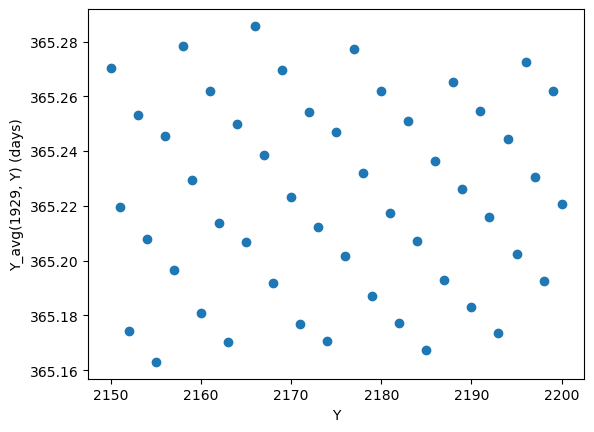

In [37]:
y1 = 1929; y2 = 2200; nyear = 50;
Ylab = 'Y'; Yavg_lab = 'Y_avg({}, Y) (days)'.format(y1)
Y, Yavg = Yavg_variation(cal, y1, y2, nyear)
Yavg_std = np.std(Yavg)
print('Y_avg 变化的均方值 = {} 日'.format(Yavg_std))
scatter_plot(Y, Yavg, Ylab, Yavg_lab)

要绘制中历月日数的变化图，需要写较长程式，但也很容易。

In [38]:
def Mavg_variation(cal, y1, y2, nmonth):
    jdn1 = cal.calData[y1 - cal.ybeg_default + 1, 0] + int(cc.getJDm(y1-1, 12, 31) + 0.6)
    jdn2 = cal.calData[y2 - cal.ybeg_default + 2, 0] + int(cc.getJDm(y2, 12, 31) + 0.6)
    N = jdn2 - jdn1
    Nleap = np.sum(cal.calData[(y1-cal.ybeg_default+1):(y2-cal.ybeg_default+2), 13] !=  0)
    Nm0 = 12*(y2-y1+1) + Nleap
    Nm = Nm0
    Mavg = np.array([N/Nm])
    y = y2
    while len(Mavg) < nmonth+1:
        # cc.NdaysGregJul(y) 输出公历年 y 的日数
        # M1 是中历 y+1 首日日期但以离公历 y 年1月0日的日数表示
        M1 = cal.calData[y - cal.ybeg_default + 2, 0] + cc.NdaysGregJul(y)
        # 获取中历 y 年所有非闰月 
        cm = list(cal.calData[y - cal.ybeg_default + 1, 0:12])
        # 加闰月（如果有）
        if cal.calData[y - cal.ybeg_default + 1, 12] != 0:
            cm += [cal.calData[y - cal.ybeg_default + 1, 12]]
        # 将中历月从迟到早排序
        cm = np.flip(np.sort(np.array(cm)))
        # 计算 Mavg 并加入 M_array
        N_array = N - M1 + cm
        Nm_array = Nm - np.arange(1, len(cm)+1)
        Mavg = np.append(Mavg, N_array/Nm_array)
        # 更新 y, N 及 Nm， 用于下一输
        y -= 1
        N = N_array[-1]
        Nm = Nm_array[-1]
    # 提取最前的 nmonth+1 elements
    if len(Mavg) > nmonth+1:
        Mavg = np.copy(Mavg[:(nmonth+1)])
    Nm = np.arange(Nm0,Nm0 - nmonth-1, -1)  
    return Nm, Mavg

M_avg 变化的均方值 = 0.00012352603795858424 日


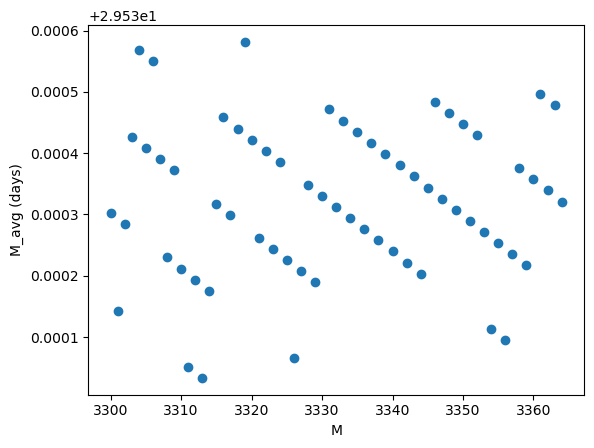

In [39]:
y1 = 1929; y2 = 2200; nmonth = 64;
Mlab = 'M'; Mavg_lab = 'M_avg (days)'
M, Mavg = Mavg_variation(cal, y1, y2, nmonth)
Mavg_std = np.std(Mavg)
print('M_avg 变化的均方值 = {} 日'.format(Mavg_std))
scatter_plot(M, Mavg, Mlab, Mavg_lab)

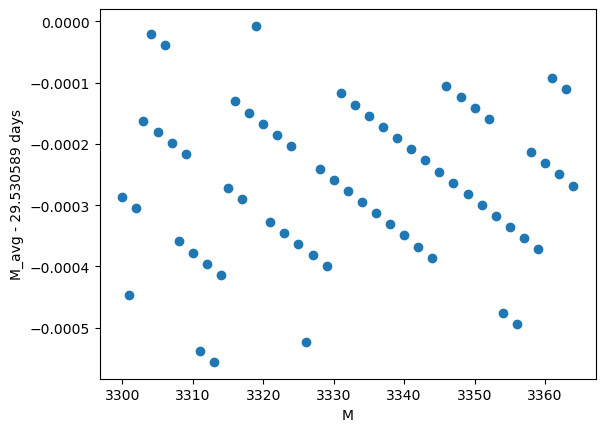

In [40]:
# M_avg - 29.530589 
M_syn = 29.530589
Mavg_lab = 'M_avg - {} days'.format(M_syn)
scatter_plot(M, Mavg-M_syn, Mlab, Mavg_lab)

现在考察更长年间：从-100年至2200年这2301年间的平均值。从[农历疑惑网页](https://ytliu0.github.io/ChineseCalendar/rules_demysterified_simp.html#averages)得知 Y_avg 和 M_avg 的变化会与刚才计算的年间降至$2301/272 \approx 8.5$倍。

Y_avg(-100, 2200) = 365.23728813559325 日
M_avg(-100, 2200) = 29.530587863241855 日
Y_avg 变化的均方值: 0.003781877931077409, 比刚才算出的值降了9.14倍
M_avg 变化的均方值: 1.4989508602877699e-05, 比刚才算出的值降了8.24倍


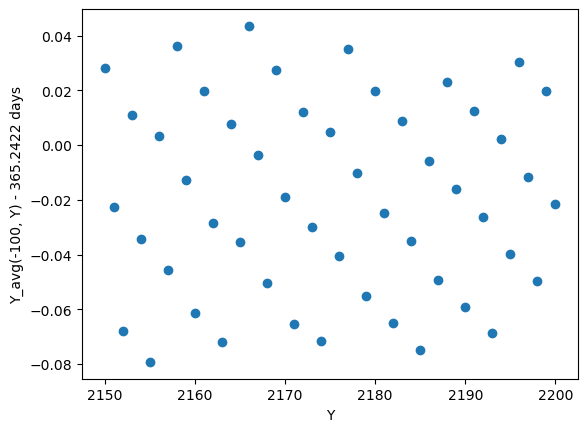

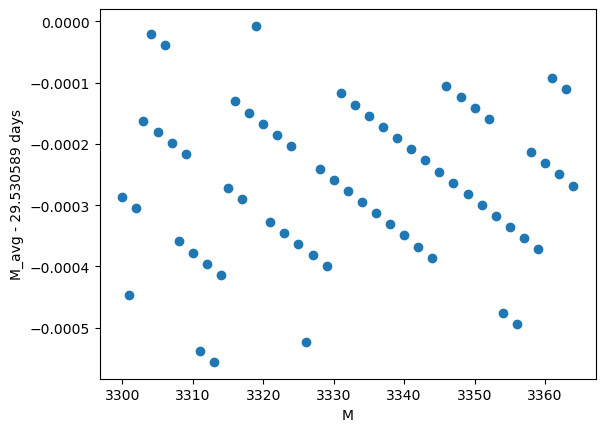

In [41]:
y1 = -100; y2 = 2200; nyear = 100; nmonth = 100; 
Y1, Y1avg = Yavg_variation(cal, y1, y2, nyear)
M1, M1avg = Mavg_variation(cal, y1, y2, nmonth)
print('Y_avg({}, {}) = {} 日'.format(y1, y2, Y1avg[0]))
print('M_avg({}, {}) = {} 日'.format(y1, y2, M1avg[0]))
Y1avg_std = np.std(Y1avg)
M1avg_std = np.std(M1avg)
fY = round(Yavg_std/Y1avg_std,2)
fM = round(Mavg_std/M1avg_std,2)
print('Y_avg 变化的均方值: {}, 比刚才算出的值降了{}倍'.format(Y1avg_std, fY))
print('M_avg 变化的均方值: {}, 比刚才算出的值降了{}倍'.format(M1avg_std, fM))
M_syn = 29.530589; Y_tropical = 365.2422;
Ylab = 'Y'; Mlab='M';
Yavg_lab = 'Y_avg({}, Y) - {} days'.format(y1, Y_tropical)
Mavg_lab = 'M_avg - {} days'.format(M_syn)
scatter_plot(Y, Yavg-Y_tropical, Ylab, Yavg_lab)
scatter_plot(M, Mavg-M_syn, Mlab, Mavg_lab)

可见中历年的平均值确是接近回归年365.2422日，中历月的平均值接近朔望月29.530589日。$Y_{\rm avg}$ 和 $M_{\rm avg}$ 在取2300年的平均值后，平均值的变化也与预朔那样大为降低。

预设中历在9-23年、237-239年、690-700年因改正朔之故与`cal.calData` array 的数据不一致。然而，只要 y1 和 y2 不在这些年份内就没有问题，因为$N(y1, y2)$ 和 $N_m(y1, y2)$ 只与 y1 和 y2 有关，两年份中间的中历年怎样划分不会影响平均值。

预设中历的年份上限是2200年，2200年后的中历可用《农历的编算和颁行》(GB/T 33661-2017)计算，现以计算1921-3000年的中历年月平均值展示计算方法。虽然2018年前的中历不用GB/T 33661-2017计算，但实历与GBT法则要到1920年及以前才见差异。

计算中历年月日数的平均值涉及用 GB/T 33661-2017 计算$N(y1, y2)$ 和 $N_m(y1, y2)$。$N(y1, y2)$ 的算法如旧，$N_m(y1, y2)$ 涉及计算中历月的数目，其中一个简单算法是用`cal.sm.st_mp_id(jd1, jd2)`获取所有在 jd1 至 jd2 的 UT 儒略日数中所有 DE 历表算出的节气和月相，然后计算朔的数目。这算法并不是最有效的，因为此函数还会计算其他不必要的东西，只是有现成函数可用，省却了另编程式。

In [42]:
def Yavg_GBT_variation(cal, y1, y2, nyear):
    jdn1 = cal.chinese_to_western_date(y1, 1, 1, 'GBT')['JDN']
    jdn2 = cal.chinese_to_western_date(y2+1, 1, 1, 'GBT')['JDN']
    N = jdn2 - jdn1
    ny = y2 - y1 + 1
    Yavg = [N/ny]
    for y in range(y2, y2-nyear, -1):
        jdn1 = cal.chinese_to_western_date(y, 1, 1, 'GBT')['JDN']
        N -= jdn2 - jdn1
        ny -= 1
        jdn2 = jdn1
        Yavg += [N/ny]
    Y = np.arange(y2, y2-nyear-1, -1)
    return Y, np.array(Yavg)

In [43]:
def Mavg_GBT_variation(cal, y1, y2, nmonth):
    jdn1 = cal.chinese_to_western_date(y1, 1, 1, 'GBT')['JDN']
    jdn2 = cal.chinese_to_western_date(y2+1, 1, 1, 'GBT')['JDN']
    N = jdn2 - jdn1
    # 需要设定 UT 儒略日数的下限 jd1 和上限 jd2 以计算中历年 y1 至 y2 的日数。
    # 已知 jdn1 为 y1 年正月朔日的 UT+8 正午儒略日数，jdn2  为 y2+1 年正月朔日的 UT+8 正午儒略日数,
    # JDN_{UT} = JDN_{UT+8} - 1/3, JD_{UT} = JDN_{UT+8} - 5/6
    # 设 jd1 = jdn1 - 0.9 及 jd2 = jdn2 + 0.2 就可保证涵盖中历年 y1 至 y2 的所有中历月的朔
    jd1 = jdn1 - 0.9 
    jd2 = jdn2 + 0.2 
    st, mp = cal.sm.st_mp_jd(jd1, jd2)
    # 获取朔的 UT＋8 正午儒略日数
    f5o6 = 5/6
    jdn = np.array([int(np.floor(x[1]['jd0_ut'] + x[1]['jd1_ut']+ f5o6)) for x in mp if x[0]=='Q0'])
    # 测试一致性
    assert(jdn1==jdn[0])
    assert(jdn2==jdn[-1])
    N_array = np.flip(jdn)[:(nmonth+1)] - jdn1
    M = len(jdn) - 1 - np.arange(nmonth+1)
    Mavg = N_array/M
    return M, Mavg

计算1921-3000年的平均值前，先检验程式，计算1929-2200年的平均值，由于GB/T 33661-2017 算出的中历在1920年及以前才与预设中历有差异，用GB/T 33661-2017 算出的929-2200年的平均值应与上面的计算值完全一致。

In [44]:
y1 = 1929; y2 = 2200; nyear = 50; nmonth = 64;
Y, Yavg_GBT_test = Yavg_GBT_variation(cal, y1, y2, nyear)
M, Mavg_GBT_test = Mavg_GBT_variation(cal, y1, y2, nmonth)
dYavg = sum(np.abs(Yavg_GBT_test - Yavg))
dMavg = sum(np.abs(Mavg_GBT_test - Mavg))
tiny = 1e-15
print('Y_avg 与上面算出的一致: ', dYavg < tiny)
print('M_avg 与上面算出的一致: ', dMavg < tiny)

Y_avg 与上面算出的一致:  True
M_avg 与上面算出的一致:  True


现在计算1921-3000年的平均值，这时段有1080年，是上面272年的$1080/272=3.97$倍，因此预期平均值变化的均方值降了相同的倍数。

Y_avg(1921, 3000) = 365.22058823529414 日
Y_avg 变化的均方值: 0.008252328287717332, 比刚才算出的值降了4.19倍


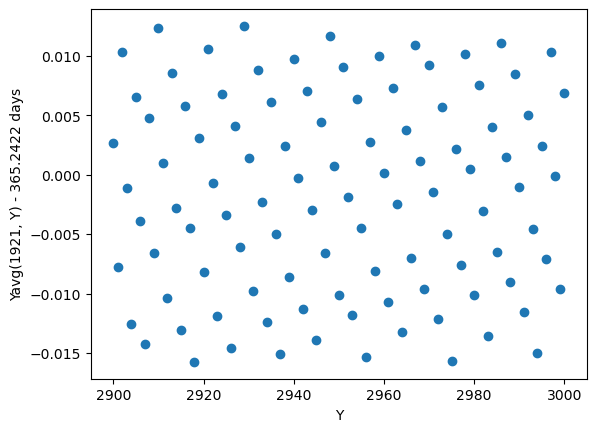

In [45]:
y1 = 1921; y2 = 3000; nyear = 100; Y_tropical = 365.2422;
Ylab = 'Y'; Yavg_lab = 'Yavg({}, Y) - {} days'.format(y1, Y_tropical)
Y, Yavg_GBT = Yavg_GBT_variation(cal, y1, y2, nyear)
Yavg_GBT_std = np.std(Yavg_GBT)
Yavg_GBT_test_std = np.std(Yavg_GBT_test)
fY = round(Yavg_GBT_test_std/Yavg_GBT_std, 2)
print('Y_avg({}, {}) = {} 日'.format(y1, y2, Yavg[0]))
print('Y_avg 变化的均方值: {}, 比刚才算出的值降了{}倍'.format(Yavg_GBT_std, fY))
scatter_plot(Y, Yavg_GBT-Y_tropical, Ylab, Yavg_lab)

M_avg(1921, 3000) = 29.53054349453511 日
M_avg  变化的均方值: 3.0126179482467743e-05, 比刚才算出的值降了4.1倍: 


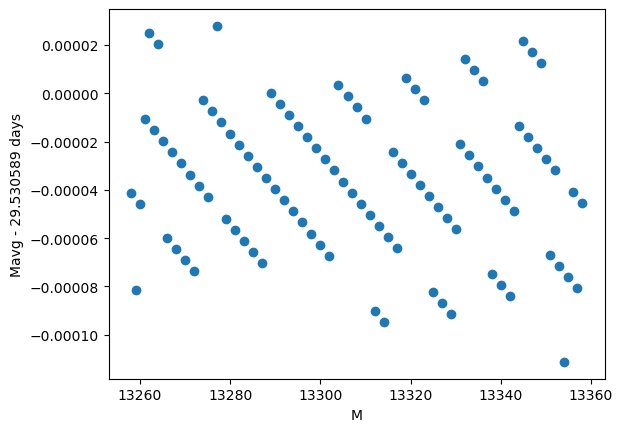

In [46]:
nmonth=100
M, Mavg_GBT = Mavg_GBT_variation(cal, y1, y2, nmonth)
Mavg_GBT_std = np.std(Mavg_GBT)
Mavg_GBT_test_std = np.std(Mavg_GBT_test)
fM = round(Mavg_GBT_test_std/Mavg_GBT_std, 2)
print('M_avg({}, {}) = {} 日'.format(y1, y2, Mavg_GBT[0]))
print('M_avg  变化的均方值: {}, 比刚才算出的值降了{}倍: '.format(Mavg_GBT_std,fM))
M_syn = 29.530589
Mlab = 'M'; Mavg_lab = 'Mavg - {} days'.format(M_syn)
scatter_plot(M, Mavg_GBT-M_syn, Mlab, Mavg_lab)

## 伪闰月和双中气月

伪闰月是清顺治二年后不含中气而又不是闰月的中历月。中国自汉太初元年(前104年)后采用无中气置闰，无中气的月份皆是闰月，但此法则在清顺治二年历改采用定气后失效，因为两中气之间的日数有长有短，短的小于三十日，于是有可能在一个月内出现两个中气(双中气)，以致可能出现一岁内有两无中气之月，称为「跨限」，为免月序混乱，多出来的无中气月不置闰，成为伪闰月，双中气月和伪闰月会成双出现。

预设中历的朔闰可用`ChineseCalendar_py.default_Chinese_year_data()`函数获取，函数在源码资料夹'src/ChineseCalendar_py'的 calendar_calculation.py 档案。历书节气存于 numpy array `cal.calSterm`，其数据取自源码资料夹档案 default_calendar_M105_2201.csv 第十六至三十九栏。其实`cal.chinese_year_info()`也提供需要的数据，只是此函数比较慢，因为函数还收集中历年内所有用现代DE历表算出的月相和十节气的UT+8时处，这些数据对搜索伪闰月没有用。

下面函数`find_fake_leap_months_two_major_solar_terms()`找出中历年 y1 至 y2 间的伪闰月和双中气月。

In [47]:
def find_fake_leap_months_two_major_solar_terms(cal, y1, y2):
    fakeLeapMonths = []
    twoMajorSolarTerms = []
    for y in range(y1, y2+1):
        ndays = cc.NdaysGregJul(y) # 公历 y 年的日数
        cmonth = cc.default_Chinese_year_data(cal, y)['cm'] # 中历 y 年所有中历月
        # 加次年正月
        cmonth += [cc.default_Chinese_year_data(cal, y+1)['cm'][0]]
        cmonth[-1]['d'] += ndays
        # 收集 y-1 年至 y+1 年的历书节气 
        Zqi = cal.calSterm[y - cal.ybeg_default, range(1,24,2)] - cc.NdaysGregJul(y-1)
        Zqi = np.append(Zqi, cal.calSterm[y - cal.ybeg_default+1, range(1,24,2)])
        Zqi = np.append(Zqi, cal.calSterm[y - cal.ybeg_default+2, range(1,24,2)] + ndays)
        n = len(cmonth)
        # 寻找伪闰月和双中气
        for m in range(n-1):
            if cmonth[m]['cm'] > 0:
                i = np.searchsorted(Zqi, cmonth[m]['d'], 'left')
                if Zqi[i] >= cmonth[m+1]['d']:
                    fakeLeapMonths += [{'中历年':chinese_year_name(cal,y), '中历月':cal.cmonth[cmonth[m]['cm']-1]}]
                if Zqi[i+1] < cmonth[m+1]['d']:
                    twoMajorSolarTerms += [{'中历年':chinese_year_name(cal,y), '中历月':cal.cmonth[cmonth[m]['cm']-1]}]
    return fakeLeapMonths, twoMajorSolarTerms

In [48]:
fakeLeapMonths, twoMajorSolarTerms = find_fake_leap_months_two_major_solar_terms(cal, 1646, 2200)
print('1646-2200年伪闰月的数目： {}'.format(len(fakeLeapMonths)))
print('1646-2200年双中气月的数目： {}\n'.format(len(twoMajorSolarTerms)))
print('1646-2200年的伪闰月:')
display(pd.DataFrame(fakeLeapMonths))
print('\n1646-2200年的双中气月:')
display(pd.DataFrame(twoMajorSolarTerms))

1646-2200年伪闰月的数目： 17
1646-2200年双中气月的数目： 17

1646-2200年的伪闰月:


,中历年,中历月
0,清世祖顺治十八年(1661年),十二月
1,清圣祖康熙十九年(1680年),十二月
2,清圣祖康熙三十九年(1700年),二月
3,清高宗乾隆四十年(1775年),十二月
4,清仁宗嘉庆十八年(1813年),九月
5,清宣宗道光十三年(1833年),正月
6,清文宗咸丰二年(1852年),二月
7,清穆宗同治九年(1870年),十二月
8,乙丑年(1985年),正月
9,癸丑年(2033年),八月



1646-2200年的双中气月:


,中历年,中历月
0,清世祖顺治十八年(1661年),十一月
1,清圣祖康熙十九年(1680年),十一月
2,清圣祖康熙三十八年(1699年),十二月
3,清高宗乾隆四十年(1775年),十一月
4,清仁宗嘉庆十八年(1813年),十月
5,清宣宗道光十二年(1832年),十一月
6,清文宗咸丰元年(1851年),十二月
7,清穆宗同治九年(1870年),十一月
8,甲子年(1984年),十一月
9,癸丑年(2033年),十一月


计算结果显示1646-2200年有十七个伪闰月和十七个双中气，每个双中气都有对应的伪闰月，其中八对出现在清朝。

In [49]:
# 汉太初二年(-102年)至顺治二年(1645年)的伪闰月和双中气
fakeLeapMonths2, twoMajorSolarTerms2 = find_fake_leap_months_two_major_solar_terms(cal, -102, 1645)
print('汉太初二年(-102年)至顺治二年(1645年)伪闰月数目: {}'.format(len(fakeLeapMonths2)))
print('汉太初二年(-102年)至顺治二年(1645年)双中气月的数目： {}\n'.format(len(twoMajorSolarTerms2)))
print('汉太初二年(-102年)至顺治二年(1645年)的伪闰月:')
print(*fakeLeapMonths2, sep='\n')

汉太初二年(-102年)至顺治二年(1645年)伪闰月数目: 1
汉太初二年(-102年)至顺治二年(1645年)双中气月的数目： 0

汉太初二年(-102年)至顺治二年(1645年)的伪闰月:
{'中历年': '清世祖顺治二年(1645年)', '中历月': '六月'}


如我在[编算农历网页](https://ytliu0.github.io/ChineseCalendar/computation_simp.html#qing)所述，顺治二年(1645年)的闰六月是唯一不遵从后来制定的置闰法则，中气大暑在闰六月初一，而六月没有中气，由于这无中气月来自新的置闰法则，而非跨限，所以没有对应的双中气月。因清朝以前用平气，不会出现伪闰月，太初二年前不用无中气置闰，当然会出现无中气月不是闰月的情况。

预设中历只去到2200年，2200年以后的伪闰月和双中气月可用本软体提供的《农历的编算和颁行》GB/T 33661-2017 方法计算，所有的资料都可从`cal.chinese_year_info()`函数获取，只是这函数用来寻找伪闰月和双中气月效率不高，考虑到寻找伪闰月和双中气月所涉及的运算与编算 GB/T 33661-2017 中历相若，这里索性重零开始编写函数。

以下函数`GBT_fake_leap_months_two_major_solar_terms(cal, y1, y2, ephemeris='DE441')`寻找从y1岁至y2岁中所有的伪闰月和双中气月，`cal`为中历class实体，`ephemeris`选择计算月相和节气的历表。函数算法与在源码资料夹'src/ChineseCalendar_py'档案'calendar_calculation.py'的`GBT33661_2017_sui()`函数算法非常接近。首先是从预先算好了的DE月相和节气TDB时刻提取合朔和中气，将时刻转换为UT+8后提取朔日和中气日朔，然后按 GB/T 33661-2017 法则编排中历月及寻找伪闰月和双中气月。

预先算好了的DE月相和节气的TDB时刻存于源码资料夹'src/ChineseCalendar_py'档案'sunMoon_DE431.csv'(DE431历表数据)和'sunMoon_DE441.csv'(DE441历表数据)中，'sunMoon_DE441.csv'是我在[农历GitHub项目](https://github.com/ytliu0/ChineseCalendar/tree/master/src)中'TDBtimes_extended.txt.gz'档案数据的删节版。设定历表后，DE月相和节气的TDB时刻数据会载入 numpy array `cal.sm.smData`。

In [50]:
def GBT_fake_leap_months_two_major_solar_terms(cal, y1, y2, ephemeris='DE441'):
    ephemeris = cal.set_ephemeris(ephemeris)
    fakeLeapMonths = []
    twoMajorSolarTerms = []
    for y in range(y1, y2+1):
        # 收集在 y 岁中 DE 历表算出的合朔及中气的 TDB 时刻
        sc =  cal.sm.smData[int(y) - cal.sm.ybeg + 1]
        jd0 = sc[0]
        # 提取 y 岁合朔(cj)和中气(st)的 UT+8 日期
        st = [int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(1,26,2)]]
        # 加入 y-1 岁最后中气(小雪)的日期，因为这中气有可能出现在 y 岁的十一月，使其成为双中气月 
        x = cal.sm.smData[int(y) - cal.sm.ybeg, 23]
        st0 = int(np.floor(x - cc.get_dTT_UT(cal.sm.smData[int(y) - cal.sm.ybeg, 0] + x, cal.sm.dalpha)))
        st = np.array([st0 - cc.NdaysGregJul(y-1)] + st)
        cj = np.array([int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(26,85,4)]])
        # 两个十一月朔日的 indices
        ibeg = np.searchsorted(cj, st[1], 'right') - 1
        iend = np.searchsorted(cj, st[-1], 'right') - 1
        # 是否需要寻找闰月？
        find_leap = (iend - ibeg == 13)
        m = 10
        ym = y - 1
        # 寻找 y 岁的伪闰月和双中气月
        for i in range(ibeg, iend):
            j = np.searchsorted(st, cj[i], 'left')
            if st[j] >= cj[i+1]:
                if find_leap:
                    # 此乃闰月 
                    find_leap = False
                else:
                    # 此乃伪闰月 
                    m += 1
                    if m > 12:
                        m -= 12
                        ym = y
                    fakeLeapMonths += [{'中历年':chinese_year_name(cal,ym), '中历月':cal.cmonth[m-1]}]
                continue
            m += 1
            if m > 12:
                m -= 12
                ym = y
            if st[j+1] < cj[i+1]:
                # 此乃双中气月
                twoMajorSolarTerms += [{'中历年':chinese_year_name(cal,ym), '中历月':cal.cmonth[m-1]}]
    return fakeLeapMonths, twoMajorSolarTerms

首先先验证此函数在1912-2200能算出正确的伪闰月和双中气月，虽然 GB/T 33661-2017 在1912-1929年算出的气朔日期与实历有差异(GB/T 33661-2017 在2018年才正式被采用为官方农历)，但伪闰月和双中气月颇为罕见，在这28年内实历就没有出现过，预料用 GB/T 33661-2017 算出的日历也不会出现，如果真发现有差异，再去检查是来自 GB/T 33661-2017 与实历之差，还是函数有错误。

In [51]:
fakeLeapMonths_1912_2200 = fakeLeapMonths[8:]
twoMajorSolarTerms_1912_2200 = twoMajorSolarTerms[8:]
fakeLeapMonths_GBT, twoMajorSolarTerms_GBT = GBT_fake_leap_months_two_major_solar_terms(cal, 1912, 2200)
print('GB/T 33661-2017 算出的 1912-2200 伪闰月与上面算出的一致: {}'.format(fakeLeapMonths_GBT==fakeLeapMonths_1912_2200))
print('GB/T 33661-2017 算出的 1912-2200 双中气月与上面算出的一致: {}'.format(twoMajorSolarTerms_GBT==twoMajorSolarTerms_1912_2200))

GB/T 33661-2017 算出的 1912-2200 伪闰月与上面算出的一致: True
GB/T 33661-2017 算出的 1912-2200 双中气月与上面算出的一致: True


测试成功，现在可用此函数计算2201-3500岁所有的伪闰月和双中气月。

In [52]:
fakeLeapMonths_GBT, twoMajorSolarTerms_GBT = GBT_fake_leap_months_two_major_solar_terms(cal, 2201, 3500)
print('2201-3500岁伪闰月数目: {}'.format(len(fakeLeapMonths_GBT)))
print('2201-3500岁双中气月数目: {}\n'.format(len(twoMajorSolarTerms_GBT)))

2201-3500岁伪闰月数目: 39
2201-3500岁双中气月数目: 39



In [53]:
print('2201-3500岁伪闰月:')
display(pd.DataFrame(fakeLeapMonths_GBT))

2201-3500岁伪闰月:


,中历年,中历月
0,乙巳年(2205年),正月
1,甲子年(2224年),二月
2,壬午年(2242年),十月
3,癸未年(2243年),正月
4,己亥年(2319年),二月
5,丁巳年(2337年),十月
6,乙酉年(2425年),正月
7,庚子年(2500年),十二月
8,己未年(2519年),十月
9,丁酉年(2557年),十二月


In [54]:
print('2201-3500岁双中气月:')
display(pd.DataFrame(twoMajorSolarTerms_GBT))

2201-3500岁双中气月:


,中历年,中历月
0,甲辰年(2204年),十一月
1,甲子年(2224年),正月
2,壬午年(2242年),十一月
3,壬午年(2242年),十二月
4,戊戌年(2318年),十一月
5,丁巳年(2337年),十一月
6,甲申年(2424年),十二月
7,庚子年(2500年),十一月
8,己未年(2519年),十一月
9,丁酉年(2557年),十一月


## 闰月分布

预设中历-103-2200年闰月资料存于 numpy array `cal.calData`的第十四行，闰月用寅正序数，0表示没有闰月，1表示闰月在建寅月后，2表示在建卯月后等。由于中国历代大多以建寅为正月，1表示闰正月，2表示闰二月年，但9-23年、237-239年的历法用丑正，690-700及762年用子正，因此月序在这些年有差异，此处不理会这些年份。

首先考察顺治二年历改后的闰月分布，先略去顺治二年的闰月，因为此年的置闰法则与其后的不同。

In [55]:
leap = cal.calData[(1646 - cal.ybeg_default + 1):, 13]
leap.shape

(557,)

In [56]:
# 除去没有闰月的数据
leap = np.copy(leap[leap > 0])
n = len(leap)
print(n)

205


,闰月,次数,百分比
0,2,17,8.292683
1,3,28,13.658537
2,4,37,18.048780
3,5,39,19.024390
4,6,34,16.585366
5,7,27,13.170732
6,8,11,5.365854
7,9,5,2.439024
8,10,4,1.951220
9,11,3,1.463415


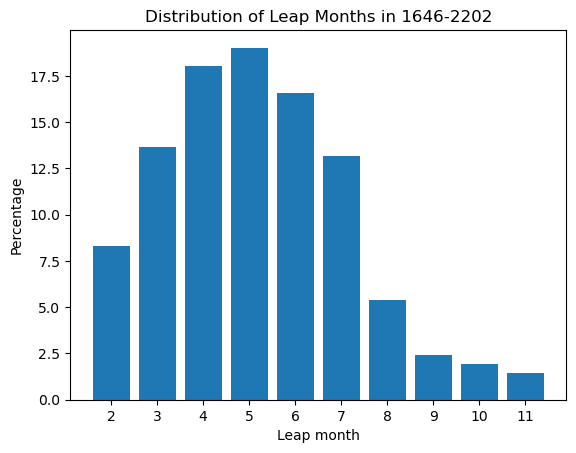

In [57]:
# 1646-2202年间有没有205个闰月
# 计算闰月出现的次数
m, freq = np.unique(leap, return_counts=True)
display(pd.DataFrame({'闰月':m, '次数':freq, '百分比':100*freq/n}))
plt.bar(m, freq/n*100)
plt.title('Distribution of Leap Months in 1646-2202')
plt.xticks(m, [str(i) for i in m])
plt.xlabel('Leap month')
plt.ylabel('Percentage')
plt.show()

从上面长条图得知闰五月出现次数最多，闰正月和闰十二月在这557年间从未出现过。

现在看看其他时段的闰月分布，以下函数提取从 y1 至 y2 年预设中历的闰月数据，然后绘制闰月分布的长条图。

In [58]:
def leap_month_dist(y1, y2):
    #Leap months in y1 - y2
    leap = cal.calData[(y1 - cal.ybeg_default + 1):(y2 - cal.ybeg_default + 2), 13]
    leap = np.copy(leap[leap > 0])
    n = len(leap)
    print('{}年-{}年的闰月数目: {}'.format(y1,y2,n))
    m, freq = np.unique(leap, return_counts=True)
    display(pd.DataFrame({'闰月':m, '次数':freq, '百分比':100*freq/n}))
    plt.bar(m, freq/n*100)
    plt.title('Distribution of Leap Months in {}-{}'.format(y1,y2))
    plt.xticks(m, [str(i) for i in m])
    plt.xlabel('Leap month')
    plt.ylabel('Percentage')
    plt.show()

-103年-1644年的闰月数目: 643


,闰月,次数,百分比
0,1,51,7.931571
1,2,47,7.309487
2,3,63,9.797823
3,4,50,7.776050
4,5,69,10.730949
5,6,48,7.465008
6,7,52,8.087092
7,8,54,8.398134
8,9,48,7.465008
9,10,62,9.642302


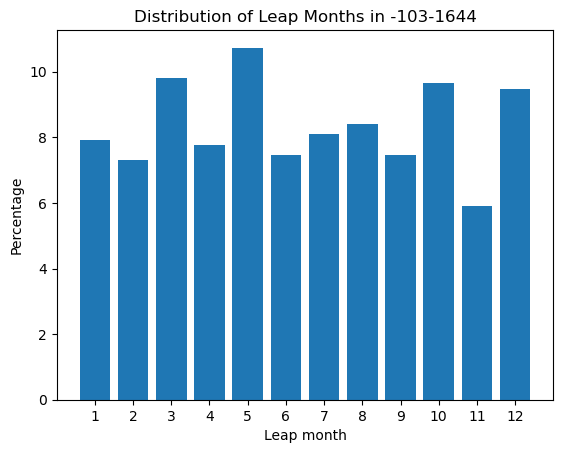

In [59]:
# 前104 - 1644年预设中历的闰月分布
leap_month_dist(-103,1644)

这段期间的节气用平气，闰月分布似乎颇为均匀，也许可用卡方适合度检定(Chi-square goodness of fit test)检验分布是否符合均匀分布，但这样做不妥当，因为闰月是用置闰法则制定的，而不是从某机率分布随机抽样，闰月法则是确定性的数学法则，不涉及随机过程。

从-103年至618年的中历用平气和平朔，置闰法则涉及的数学计算比较简单，试看这段期间的闰月分布。

-103年-618年的闰月数目: 265


,闰月,次数,百分比
0,1,25,9.433962
1,2,12,4.528302
2,3,30,11.320755
3,4,15,5.660377
4,5,32,12.075472
5,6,18,6.792453
6,7,20,7.547170
7,8,25,9.433962
8,9,17,6.415094
9,10,31,11.698113


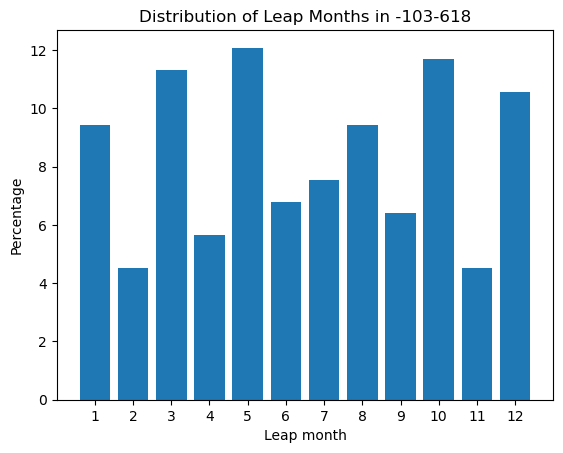

In [60]:
leap_month_dist(-103, 618)

可见这段期间的闰月分布并不均匀，图中显示闰正月、闰三月、闰五月、闰八月、闰十月、闰十二月比其他闰月出现的次数较多。

平气和平朔的置闰法则有周期性，例如太初/三统历选取的回归年:朔望月=235:19，由此可推出十九年有七个闰月，而闰月有七十六年的周期(二十八个闰月)。太初/三统历于汉武帝太初元年(-103年)至汉章帝建初八年(83年)行用，可验证这七十六年周期。

In [61]:
leap = cal.calData[(-103 -cal.ybeg_default+1):(83-cal.ybeg_default+2), 13]
leap = np.copy(leap[leap >0])
len(leap)

68

这期间有68个闰月，两个完整周期加上十二个闰月。先检验头28个闰月是否与接着的二十八个闰月完全一致。

In [62]:
leap[:28]==leap[28:56]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

数据证实了预期的周期，再看余下的十二个闰月是否与头十二个闰月一致:

In [63]:
leap[56:]==leap[:12]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

注意新朝(9-23年)用丑正，因此月序与寅正差一个月，但这完全不影响验证结果，如前述，`cal.calData`的月序用寅正数据，而不是当时的丑正数据。

现在看看这七十六年周期，二十八个闰月的分布:

,闰月,次数,百分比
0,1,3,10.714286
1,2,1,3.571429
2,3,3,10.714286
3,4,2,7.142857
4,5,3,10.714286
5,6,2,7.142857
6,7,2,7.142857
7,8,3,10.714286
8,9,2,7.142857
9,10,3,10.714286


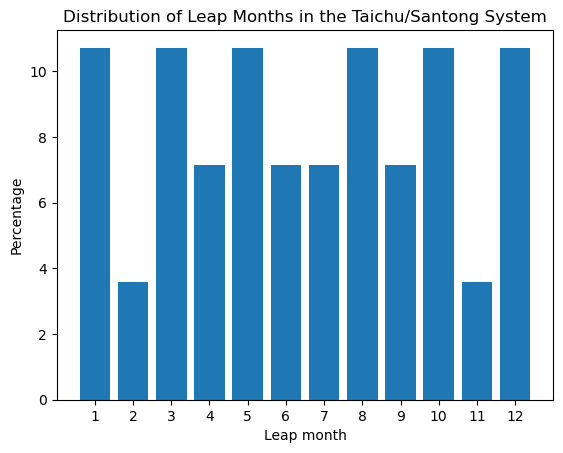

In [64]:
m, freq = np.unique(leap[:28], return_counts=True)
display(pd.DataFrame({'闰月':m, '次数':freq, '百分比':100*freq/28}))
plt.bar(m, freq/28*100)
plt.xticks(m, [str(i) for i in m])
plt.title('Distribution of Leap Months in the Taichu/Santong System')
plt.xlabel('Leap month')
plt.ylabel('Percentage')
plt.show()

这就是用太初/三统历置闰法则得出的闰月分怖，明显不是均匀分布。在这28个闰月中，闰正月、闰三月、闰五月、闰八月、闰十月和闰十二月各自出现三次，闰四月、闰六月、闰七月和闰九月各自出现二次，闰二月和闰十一月各自出现一次。

在唐高祖武德二年(619年)至唐太宗贞观十九年(645年)及唐高宗麟德二年(665年)至明思宗崇祯十七年(1644年)间预设中历用平气和定朔，此处只看麟德二年(665年)至崇祯十七年(1644年)的闰月分布。

665年-1644年的闰月数目: 361


,闰月,次数,百分比
0,1,25,6.925208
1,2,33,9.141274
2,3,31,8.587258
3,4,34,9.418283
4,5,36,9.972299
5,6,29,8.033241
6,7,30,8.310249
7,8,28,7.756233
8,9,30,8.310249
9,10,28,7.756233


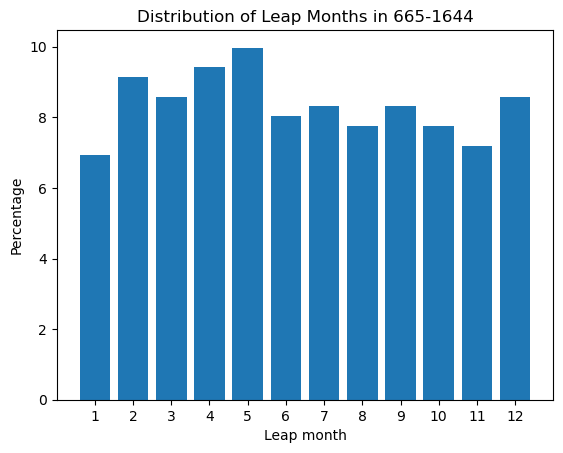

In [65]:
leap_month_dist(665, 1644)

可见此期间的闰月分布接近均匀分布，有可能是定气法使朔日在平朔的朔日一两日间浮动，打乱了平气平朔的闰月规率，又有可能是这段期间中历频频改历，打乱了一套历法应有的闰月规律。

要知道频频改历是否是主因，试看明太祖洪武元年(1368年)至明思宗崇祯十七年(1644年)间的闰月分布，这时期的中历都用大统历。

1368年-1644年的闰月数目: 102


,闰月,次数,百分比
0,1,6,5.882353
1,2,11,10.784314
2,3,7,6.862745
3,4,13,12.745098
4,5,7,6.862745
5,6,10,9.803922
6,7,8,7.843137
7,8,7,6.862745
8,9,10,9.803922
9,10,5,4.901961


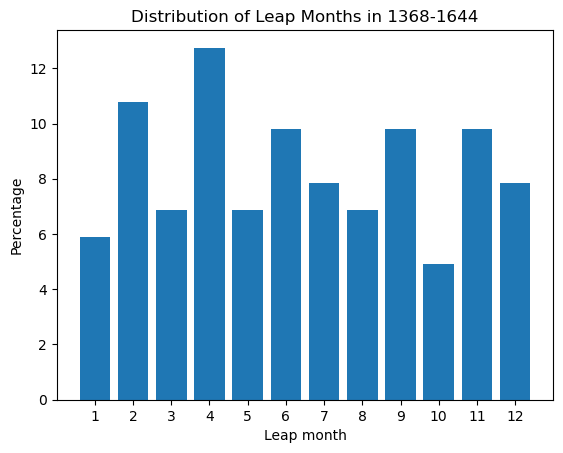

In [66]:
leap_month_dist(1368, 1644)

数据似乎显示闰月分布不均匀，但也可能是年数不够多，未能显示闰月的真正分布。为了解决这问题，我用大统历逆推645-1367年的闰月，然后考察大统历在645-1644年这一千年的闰月分布。这一千年间依大统历算也有361个闰月，闰正月至闰十二月出现的次数依次是32、29、34、32、34、33、26、32、30、25、27和27。本软体套件没有提供大统历的计算函数，数据是我用C++程式算出的。

,闰月,次数,百分比
0,1,32,8.864266
1,2,29,8.033241
2,3,34,9.418283
3,4,32,8.864266
4,5,34,9.418283
5,6,33,9.141274
6,7,26,7.202216
7,8,32,8.864266
8,9,30,8.310249
9,10,25,6.925208


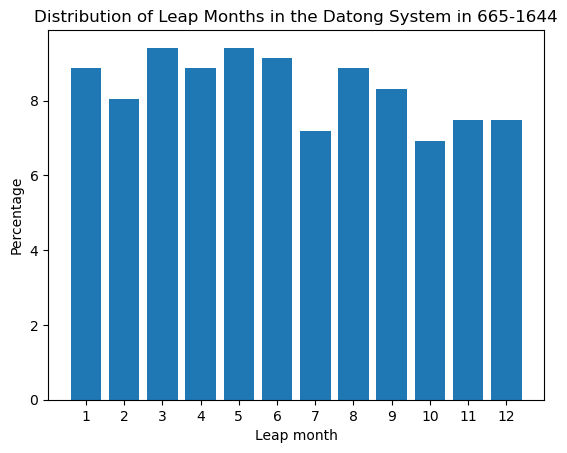

In [67]:
m = np.arange(1,13)
freq = np.array([32, 29, 34, 32, 34, 33, 26, 32, 30, 25, 27, 27])
n = sum(freq)
display(pd.DataFrame({'闰月':m, '次数':freq, '百分比':100*freq/n}))
plt.bar(m, freq/n*100)
plt.title('Distribution of Leap Months in the Datong System in 665-1644')
plt.xlabel('Leap month')
plt.xticks(m, [str(i) for i in m])
plt.ylabel('Percentage')
plt.show()

可见大统历在这一千年间的闰月接近均匀分布，因此确实有一套用平气定朔的无中气置闰法则得出接近均匀分布的闰月。

## 为什么的闰正月和闰十二月特别罕见?

这里的计算结果已收录在我的[论罕见的闰正月和闰十二月](https://ytliu0.github.io/ChineseCalendar/leap_month_1_12_simp.html)网页。

从上面的分析得知自顺治二年(1645年)改用定气后，闰正月和闰十二月在1645-2200年这557年间从未出现过，那么何时才会出现闰正月和闰十二月? 它们为什么这么罕见?

可以用《农历的编算和颁行》GB/T 33661-2017 计算2200年后至3500年的闰月，看看有没有闰正月和闰十二月。本软体套件提供的`cal.chinese_year_info()`函数可用来计算中历 y 年的中历资料，但用此函数单是算闰月效率不高，不如自己再写函数专门算闰月。

以下`leap_months_GBT(cal, y1, y2, ephemeris='DE441')`函数用《农历的编算和颁行》GB/T 33661-2017 法则计算从 y1 岁至 y2 岁所有闰月和相邻两中气的平均日数(稍后有用)，程式算法与在源码资料夹'src/ChineseCalendar_py'档案'calendar_calculation.py'中的`GBT33661_2017_sui()`函数很接近。

In [68]:
def leap_months_GBT(cal, y1, y2, ephemeris='DE441'):
    ephemeris = cal.set_ephemeris(ephemeris)
    leapm = []
    avg_dZ = np.zeros(12)
    for y in range(y1, y2+1):
        sc =  cal.sm.smData[int(y) - cal.sm.ybeg + 1]
        jd0 = sc[0]
        # 提取在 y 岁内的中气(st)和朔
        st = np.array([int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(1,26,2)]])
        cj = np.array([int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(26,85,4)]])
        avg_dZ += np.diff(st)
        # 两个十一月的 indices
        ibeg = np.searchsorted(cj, st[0], 'right') - 1
        iend = np.searchsorted(cj, st[-1], 'right') - 1
        find_leap = (iend - ibeg == 13)
        if not find_leap: 
            continue
        m = 10
        ym = y-1
        for i in range(ibeg, iend):
            if find_leap:
                qi = st[np.searchsorted(st, cj[i], 'left')]
                if qi >= cj[i+1]:
                    find_leap = False
                    leapm += [{'y':ym, 'm':m}]
                    break
            m += 1
            if m > 12: 
                m -= 12
                ym = y
    avg_dZ /= y2 - y1 + 1
    sterm = ['冬至(十一月中)', '大寒(十二月中)', '雨水(正月中)', '春分(二月中)', 
             '谷雨(三月中)', '小满(四月中)', '夏至(五月中)', '大暑(六月中)',
             '处暑(七月中)', '秋分(八月中)', '霜降(九月中)', '小雪(十月中)', '冬至(十一月中)']
    interval = ['{} - {}'.format(sterm[i], sterm[i+1]) for i in range(12)]
    return {'leap':leapm, 'avgdZ':{'中气区间':interval, '平均日数':avg_dZ}}

用这函数计算1921岁-3500岁的闰月:

In [69]:
lmGBT = leap_months_GBT(cal, 1921,3500)
# 集合闰月数据
leapm = [x['m'] for x in lmGBT['leap']]
print(len(leapm))

582


可见这期间有582个闰月，以下绘制闰月分布的归一化直方图。

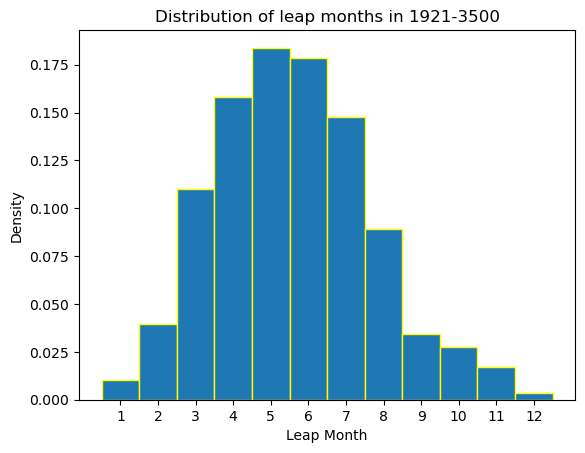

In [70]:
plt.hist(leapm, bins=np.arange(13)+0.5, edgecolor='yellow', density=True)
plt.title('Distribution of leap months in 1921-3500')
plt.xlabel('Leap Month')
plt.ylabel('Density')
plt.xticks(np.arange(1,13))
plt.show()

这归一化直方图与上面1645年-2200年的闰月分布长条图很接近，不过看见了闰正月和闰十二月。且看这两种罕见的闰月出现在何年。

In [71]:
lm1 = [x['y'] for x in lmGBT['leap'] if x['m']==1]
lm12 = [x['y'] for x in lmGBT['leap'] if x['m']==12]
print('1921-3500岁闰正月出现次数: {}'.format(len(lm1)))
print('1921-3500岁闰十二月出现次数: {}'.format(len(lm12)))

1921-3500岁闰正月出现次数: 6
1921-3500岁闰十二月出现次数: 2


In [72]:
print('1921-3500岁闰正月出现的中历年: ', lm1)
print('1921-3500岁闰十二月出现的中历年: ', lm12)

1921-3500岁闰正月出现的中历年:  [2262, 2357, 2520, 2539, 2634, 3120]
1921-3500岁闰十二月出现的中历年:  [3358, 3472]


可见闰正月和闰十二月确是罕见，下一次闰正月会出现在2262年(壬寅年)，而闰十二月要到中历3358年(戊午年)才会出现。

出现闰正月的必要条件是无中气月出现在雨水(2月19日左右)和春分(3月21日左右)之间，出现闰十二月的必要条件是无中气月出现在大寒(1月21日左右)和雨水(2月19日左右)之间。这两种闰月之罕见，一般解释是说地球在近世纪于1月初过近日点，这期间地球运行比较快，使大寒与雨水及雨水与春分间的日数相对较小，无中气月出现在相邻两中气间的次数也因此较少，但以下分析显示这只是部分原因。

请看在<span class="nowrap">S<sub>1921</sub></span> &ndash; <span class="nowrap">S<sub>3500</sub></span>间相邻两中气间之平均日数:

In [73]:
avgZ = pd.DataFrame(lmGBT['avgdZ'])
display(avgZ)

,中气区间,平均日数
0,冬至(十一月中) - 大寒(十二月中),29.482911
1,大寒(十二月中) - 雨水(正月中),29.526582
2,雨水(正月中) - 春分(二月中),29.805063
3,春分(二月中) - 谷雨(三月中),30.256329
4,谷雨(三月中) - 小满(四月中),30.760127
5,小满(四月中) - 夏至(五月中),31.186709
6,夏至(五月中) - 大暑(六月中),31.408228
7,大暑(六月中) - 处暑(七月中),31.365823
8,处暑(七月中) - 秋分(八月中),31.065190
9,秋分(八月中) - 霜降(九月中),30.598101


In [74]:
# 依平均日数排序
display(avgZ.sort_values('平均日数'))

,中气区间,平均日数
0,冬至(十一月中) - 大寒(十二月中),29.482911
1,大寒(十二月中) - 雨水(正月中),29.526582
11,小雪(十月中) - 冬至(十一月中),29.692405
2,雨水(正月中) - 春分(二月中),29.805063
10,霜降(九月中) - 小雪(十月中),30.094937
3,春分(二月中) - 谷雨(三月中),30.256329
9,秋分(八月中) - 霜降(九月中),30.598101
4,谷雨(三月中) - 小满(四月中),30.760127
8,处暑(七月中) - 秋分(八月中),31.065190
5,小满(四月中) - 夏至(五月中),31.186709


可见闰月的出现次数与相邻两中气间的平均日数确有密切关系，夏至(五月中)至大暑(六月中)的平均日数最大，预示闰五月应该最常见，事实上确是如此。如果假设平均日数与闰月出现的次数成反比，则从表中数据推断闰月出现次数从多至少的次序应该是:闰五月、闰六月、闰四月、闰七月、闰三月、闰八月、闰二月、闰九月、闰正月、闰十月、闰十二月和闰十一月，这次序确与上面归一化直方图的结果大致符合，但在闰九月后的次序错了。冬至(十一月中) 至大寒(十二月中)的平均日数最小，但闰十一月并不是最罕见的闰月，由此可见仅凭相邻两中气间的平均日数不足以解释为什么闰正月和闰十二月最罕见，肯定还有其他原因。

如前述，无中气月是闰月的必要条件。[现代农历法则](https://ytliu0.github.io/ChineseCalendar/rules_simp.html)规定，闰月出现在闰岁中冬至后第一个无中气月，双中气月和伪闰月的出现使情况变得复杂。

大寒(十二月中) 至雨水(正月中)间的无中气月及雨水(正月中) 至春分(二月中)间的无中气月在近几个世纪确实出现过，例如，清穆宗同治九年(1870年)的大寒与同治十年雨水之间就有一个无中气月，但这无中气月出现在平岁中，所以不能置闰而成为伪闰月，同治九年冬至和大寒都落在十一月，下一个月份没有中气。农历1984年(甲子年)雨水与春分之间有无中气月，是闰正月的必要条件，但这无中气月出现在平岁中，因此同样是伪闰月，此岁的冬至和大寒都落在十一月，下一个月份没有中气。农历2034年(甲寅年)雨水与春分之间有无中气月，是闰正月的必要条件，虽然这无中气月出现在闰岁中，但是这是此岁的第二个无中气月，错失了闰正月的资格而成为伪闰月，农历2033年(癸丑年)的大雪和冬至都落在十一月，下一个月是无中气月，又是闰岁中冬至后的第一个无中气月而成为闰十一月，然后大寒和雨水都落在十二月，下一个月是闰岁中的第二个无中气月，成为伪闰月。

雨水和春分间的无中气月会出现在2053年(癸酉年)、2129年(己丑年)、2148年(戊申年)、2167年(丁卯年)、2205年(乙巳年)及2243年(癸未年)，但情况与上述一样，无中气月出现在平岁中或是闰岁中的第二个无中气月，所是都是伪闰月。这情况要到2262年(壬寅年)才有转变，那会是自顺治二年来六百多年间首次出现的闰正月。大寒与雨水之间的无中气月会出现在2500年(庚子年)、2557年(丁酉年)、2595年(乙亥年)、2777年(丁丑年)、2872年(壬子年)、2891年(辛未年)及2986年(丙子年)，但全部都是伪闰月，闰十二月要到中历3358年(戊午年)才会出现。

地球在近日点附近运行快使在这附近的中气日期间隔较短，不但减少了在这些中气之间无中气月的出现，还增加了双中气月出现的频率。朔望月的平均值是29.530589日，如果相邻两中气的平均日数小于此数，则出现两中气同在一个农历月的频率多于出现在两中气之间的无中气月<sup>\*</sup>。观乎上面两中气区间平均日数表得知有两个中气区间的平均日数小于29.53日:冬至(十一月中)至大寒(十二月中)和大寒(十二月中)至雨水(正月中)，所以出现含冬至和大寒的双中气月频率多于出现在冬至和大寒之间的无中气月; 出现含大寒和雨水的双中气月频率多于出现在大寒和雨水之间的无中气月。计算显示在1921-3500年间，含冬至和大寒的双中气月有17个，冬至和大寒之间的无中气月有10个，含大寒和雨水的双中气月有14个，大寒和雨水之间的无中气月有9个，此数据证实了理论的预测。这两种双中气月的出现使情况变得非常有趣。

<hr>
<sup>*</sup> 或许有人会疑惑如果两中气的时间小于朔望月，怎可能在中间出现无中气月。答案是农历日始于朔日的午夜，而不是合朔时刻，现举2034岁的闰十一月为例说明。此岁的冬至在2033年12月21日 21:46 (UTC+8)，大寒在2034年1月20日 8:27 (UTC+8)，两中气之间的时间间隔是29.445日，但两中气日之间的日数是30日。有朔出现在12月22日 2:46 (UTC+8)，下一个朔在1月20日 18:02 (UTC+8)，两朔的时间间隔是 29.636日，大于两中气之间的时间间隔，但两朔日之间的日数是29，小于两中气日之间的日数。第一个朔日对应的农历月始于12月21日的零时(而不是合朔时刻 2:46)，终于1月20日零时(而非合朔时刻18:02)，由于此月不含中气而且是闰岁中冬至后第一个无中气月，按农历法则定为闰十一月。虽然第二个合朔时刻迟于大寒时刻，大寒与朔日仍在同一日，属第二个合朔对应的农历月。
<hr>

先分析如果含冬至和大寒的双中气月出现时的情况。由于冬至在这双中气月中，根据现代农历法则这双中气月是十一月。农历月的日数是29日或30日，从上面中气区间日数表得知冬至至大寒的平均日数是29.48日，由此推出冬至在十一月初、大寒在十一月末，也可推出这十一月出现在平岁中，因为闰岁的冬至出现在十一月(大概)十九日以后<sup>\*\*</sup>。平岁有十二个农历月，冬至至下一个岁的冬至之间有十二个中气:十一月中(冬至)、十二月中(大寒)、正月中(雨水)、二月中(春分)、三月中(谷雨)、四月中(小满)、五月中(夏至)、六月中(大暑)、七月中(处暑)、八月中(秋分)、九月中(霜降)和十月中(小雪)。已知冬至和大寒都在十一月，余下的十个中气落在余下的十一个月中，所以必然有一个无中气月，但平岁没有闰月，当中的无中气月只能是伪闰月。用 F 表示这无中气月，F-1 表示 F 之前的那个月，F+1 表示 F 之后的那个月。由于 F 是无中气月，而中气区间表显示相邻两中气的平均日数是29.48日至31.41日之间。由此推出必有一个中气出现在 F-1 的月末，另一中气出现在 F+1 的月初。已知大寒出现在十一月末，十一月有可能就是 F-1，而 F 是十二月，出现在大寒与雨水之间，但大寒与雨水的平均日数是29.53日，未必有足够多的日数容纳一个农历月，所以伪闰月 F 或会推迟到正月而出现在雨水与春分之间或更迟。这情况的实例是1985岁，伪闰月是正月，出现在雨水与春分之间。另一例是1871岁，伪闰月是十二月，出现在大寒与雨水之间。

<hr>
<sup>**</sup> 冬至在十一月的日数和"闰余"的概念相似，闰余指冬至的月龄，即冬至离之前合朔的日数。回归年有365.2422日，朔望月的平均日数是29.530589日。因365.2422 = 12&times;29.530589 + 10.875 = 13&times;29.530589 - 18.655，如果本岁是平岁，则下一岁的闰余增加约10.875日，这是平均值，由于用定朔定气，实际的日数在平均值一两日间浮动; 如果本岁是闰岁，则下一岁的闰余减小18.655日(平均值)。从闰余的定义得知闰余在0与朔望月之间，所以如果本岁的闰余超过约18.655日，本岁是闰岁。闰余18.655日约相当于冬至在十一月十九日或二十日，所以冬至出现在十一月初的岁是平岁，出现在十一月末是闰岁。
<hr>

现在分析含大寒和雨水的双中气月，用 D 表示这月，D-1 表示之前的那个月，D+1 表示之后的那个月等。大寒必然在 D 的月初，雨水必在月末。D 有两种可能的情况。

第一种可能是冬至在 D-1，换言之D-1是十一月，D 是十二月。由于大寒在十二月初，冬至必在十一月初，所以 D 是平岁的十二月。平岁有十二个月，已知十一月中(冬至)在十一月，十二月中(大寒)和正月中(雨中)都在十二月，余下的九个中气(二月中至十月中)必然在余下的十个月(正月至十月)中，所以有一个无中气月。由于平岁没有闰月，所有无中气月都变成伪闰月。伪闰月可能在雨水与春分之间或迟些。这情况的实例是2148岁，伪闰月在雨水与春分之间。

第二种可能是 D-1 是无中气月，而冬至在 D-2 的月末，即是说D-2 是闰岁的十一月，D-1 是闰岁中冬至后第一个无中气月，按农历编算法则是闰十一月，D 仍是十二月但在闰岁中。闰岁有十三个月，已知十一月中(冬至)在十一月，闰十一月无中气，十二月中(大寒)和正月中(雨水)都在十二月，余下的九个中气(二月中至十月中)必然在余下的十个月(正月至十月)中，所以有一个无中气月。由于这无中气月不是闰岁冬至后的第一个无中气月，又是伪闰月，伪闰月可能出现在雨水和春分之间或迟些。这情况的实例是2034岁，伪闰月出现在雨水和春分之间。如我在 [农历编算例子网页](https://ytliu0.github.io/ChineseCalendar/examples_simp.html#ex2)所述，农历2033年和2034年很特别，不单2033年十二月是双中气月，十一月也是双中气月，含小雪和冬至，另有无中气月在2033年七月后的那个月，由于2033岁是平岁，不能置闰，这无中气月又是伪闰月。

由此可见在大寒和雨水之间的无中气月及在雨水和春分之间的无中气月确是较为罕见，当这两种无中气月出现时，往往又伴随着双中气月而变为伪闰月。要知道"丢失"的闰正月和闰十二月是否隐藏在伪闰月中，可以找出所有的无中气月，看看是否能得到与中气区间日数预示的频率次序。

以下函数计算从 y1 岁到 y2 岁的无中气月，出现在正月中(雨水)和二月中(春分)之间的无中气月无论是闰正月还是伪闰月都用'1'来记，出现在二月中(春分)和三月中(谷雨)之间的无中气月无论是闰二月还是伪闰月都用'2'来记，其他无中气月也用类似的记法。以下函数只是稍为改了上面的`leap_months_GBT()`函数。

In [75]:
def no_Zhongqi_months_GBT(cal, y1, y2, ephemeris='DE441'):
    ephemeris = cal.set_ephemeris(ephemeris)
    nZ = []
    for y in range(y1, y2+1):
        sc =  cal.sm.smData[int(y) - cal.sm.ybeg + 1]
        jd0 = sc[0]
        # 提取在 y 岁内的中气(st)和朔
        st = np.array([int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(1,26,2)]])
        cj = np.array([int(np.floor(x - cc.get_dTT_UT(jd0 + x, cal.sm.dalpha))) for x in sc[range(26,85,4)]])
        # 两个十一月的 indices
        ibeg = np.searchsorted(cj, st[0], 'right') - 1
        iend = np.searchsorted(cj, st[-1], 'right') - 1
        for i in range(ibeg+1, iend):
            j = np.searchsorted(st, cj[i], 'left')
            if st[j] >= cj[i+1]:
                nZ += [j+10 if j < 3 else j-2]
    return np.array(nZ)

In [76]:
# 1921-3500 岁的无中气月
nZ = no_Zhongqi_months_GBT(cal, 1921, 3501)
len(nZ)

630

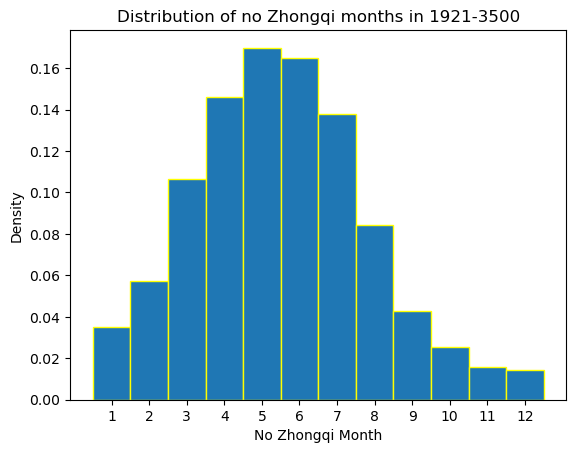

In [77]:
plt.hist(nZ, bins=np.arange(13)+0.5, edgecolor='yellow', density=True)
plt.title('Distribution of no Zhongqi months in 1921-3500')
plt.xlabel('No Zhongqi Month')
plt.ylabel('Density')
plt.xticks(np.arange(1,13))
plt.show()

In [78]:
print('冬至和大寒之间的无中气月数目: {}'.format(sum(nZ==11)))
print('大寒和雨水之间的无中气月数目: {}'.format(sum(nZ==12)))
print('雨水和春分之间的无中气月数目: {}'.format(sum(nZ==1)))

冬至和大寒之间的无中气月数目: 10
大寒和雨水之间的无中气月数目: 9
雨水和春分之间的无中气月数目: 22


可见各无中气月的出现频率基本上符合与相邻两中气的日数成反比的关系，唯一例外是在十一月中至十二月中之间的无中气(标记'11')与在十二月中至正月中之间的无中气月(标记'12')的次序颠倒了，但是两者都很小而且只是差了一个而已，极有可能是因为罕见(1580岁中只出现了10次和9次)而数据不足，无法反映真实频率。

图中的 '1' 与 '12' 频率明显大大多于闰正月和闰十二月的频率，显示'1'和 '12' 的无中气月确是隐藏在伪闰月中。'1' 的无中气月在1921岁至3500岁的数目是22，出现频率多于'10'、'11' 和 '12'，但其中16个无中气月变成伪闰月，以致闰正月数目只有6个，频率少于闰十月和闰十一月的频率，所以闰正月被双中气月抑制了。

同样，'12' 的无中气月与 '11' 的无中气月频率接近，这也是意料之中，因为从中气区间平均日数表得知十二月中至正月中的平均日数是29.526日，而十一月中至十二月中的平均日数是29.483日，两者只差0.043日。但是'12'的9个无中气月中其中7个变成了伪闰月，剩下的2个成为闰十二月，闰十二月也被双中气月抑制了。

'11' 的无中气月数目是10，虽然数目小，但全部是闰十一月，闰十一月完全没有被双中气月抑制，这也不难理解，因为伪闰月不可能出现在冬至与大寒之间。设 N 是出现在冬至与大寒之间的无中气月，N-1 是之前那个月，N+1 是之后那个月等，则冬至在 N-1 的月末，大寒在 N+1 的月初，所以 N-1 是闰岁中的十一月，N 是闰岁中冬至后第一个无中气月，根据现代农历法则 N 必然是闰十一月，所以 '11' 的无中气月都是闰十一月。

顺治二年(1645年)之前的中历用平朔计算二十四节气，两中气的时间间隔是常数并且大于三十日，由于中历月最多三十日，不可能出现双中气月，定无中气月为闰月就解决了置闰问题。改用定气后，两中气之间的日数不是常数，而且可以小于三十日，于是有可能出现双中气月。由于一岁的中气数目一般是十二，平岁有十二个月，闰岁有十三个月，如果有双中气月出现在平岁中，其余十个中气就会落在余下的十一个月中，导致多了一个无中气月成为伪闰月;如果有双中气月出现在闰岁中，其余十个中气就会落在余下的十二个月中，导致闰岁有两个无中气月，其中一个是闰月，另一个是伪闰月。因此双中气月的出现使无中气月的数目多于闰月所需的数目，额外的无中气月成为伪闰月。正月中至二月中的无中气月('1')以及出现在十二月中至正月中的无中气月('12')有一大部分成为伪闰月。这两种无中气月数目本来已经不多('1'在1921-3500岁的数目是22，'12' 的数目是9)，伪闰月的出现进一部减少了闰正月和闰十二月的数目，使闰正月和闰十二月变得非常罕见。